# **PyMC Price Target Model V2**

## Price Target Achievement — Hierarchical Student-t Regression

Schema-aligned with:
- MV: `pml.mv_pymc_price_target`
- Catalogue: `SELECT * FROM pml.vw_pymc_feature_catalogue WHERE model_target = 'price_target'`

Likelihood:
- `feat_pt_achievement_1y ~ StudentT(ν, μ_isin, σ_isin)` (heavy-tailed analyst noise)
- `μ_isin = α_sector[sector] + X_std · β`
- `σ_isin = σ_base / sqrt(n_analysts)` (precision-weighted by analyst count)


In [1]:
%%sql
SELECT * FROM pml.mv_pymc_price_target WHERE feat_pt_achievement_1y IS NOT NULL AND income_statement_report_date > '2025-01-01'

,isin,ticker,region,country,trading_country,exchange,unit,style_class,size_class,sector,...,feat_ev_ebitda_ntm,feat_vol_3m,feat_analyst_rating,feat_pt_achievement_1y,feat_pt_accuracy_1y,feat_pt_optimism_bias,feat_pt_range_hit_rate,feat_pt_median_vs_mean_spread,feat_pt_high_low_convergence_1y,feat_analyst_count_stability
0,US67066G1040,NVDA,United States and Canada,US,US,NasdaqGS,USD,Growth,Large Cap,Information Technology,...,17.5,37.70,4.70,1.000000,0.278547,-0.278547,1,0.040380,0.431214,1.029586
1,US0378331005,AAPL,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,Information Technology,...,25.9,21.67,4.02,1.000000,0.362485,-0.362485,0,0.001635,0.040301,1.048780
2,US55287L1017,MBX,United States and Canada,US,US,NasdaqGS,USD,Core,Small Cap,Health Care,...,NaN,75.13,4.50,0.826471,0.173529,0.173529,1,-0.012987,0.645865,1.434783
3,US4511071064,IDA,United States and Canada,US,US,NYSE,USD,Core,Mid Cap,Utilities,...,14.3,18.83,4.11,1.000000,0.097901,-0.097901,0,-0.025478,0.173472,1.080000
4,US53635D2027,LQDA,United States and Canada,US,US,NasdaqCM,USD,Core,Small Cap,Health Care,...,11.0,73.71,4.88,1.000000,0.985397,-0.985397,0,-0.005725,-0.801409,0.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6057,BRVVEOACNOR0,VVEO3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Health Care,...,5.0,80.15,2.43,0.677408,0.322592,0.322592,1,0.187500,-0.100000,0.750000
6058,BRQUALACNOR6,QUAL3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Health Care,...,2.3,69.34,3.22,0.628905,0.371095,0.371095,0,0.052632,-0.471840,1.000000
6059,EGS38211C016,MICH,Africa / Middle East,EG,EG,CASE,EGP,Value,Small Cap,Materials,...,6.3,54.62,4.00,1.000000,0.146338,-0.146338,0,0.000000,0.206158,2.000000
6060,BRLJQQACNOR5,LJQQ3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Consumer Discretionary,...,9.7,76.05,4.33,0.320843,0.679157,0.679157,0,0.092583,-0.529167,0.818182


## 1.1 PriceTargetModel-aligned Data Preparation

In [2]:
%%sql
SELECT *
FROM pml.vw_pymc_feature_catalogue
WHERE model_target = 'price_target'
ORDER BY pymc_role, feature_role, feature_alias

,model_target,pymc_role,column_name,category,feature_role,feature_alias,data_type,description
0,price_target,constant_data,num_strong_sell_ratings,analyst_ratings,count,feat_analyst_bearish_pct,integer,Number of strong sell ratings
1,price_target,constant_data,num_strong_buys_ratings,analyst_ratings,count,feat_analyst_bullish_pct,integer,Number of strong buy ratings
2,price_target,constant_data,num_sell_ratings,analyst_ratings,count,feat_analyst_conviction,integer,Number of sell ratings
3,price_target,constant_data,num_buys_ratings,analyst_ratings,count,feat_analyst_neutral_pct,integer,Number of buy ratings
4,price_target,constant_data,num_hold_ratings,analyst_ratings,count,feat_holds,integer,Number of hold ratings
...,...,...,...,...,...,...,...,...
135,price_target,observed,target_pct_low,analyst_targets,target,feat_target_range_width_low,double precision,Implied upside vs. low analyst target (%)
136,price_target,observed,target_pct_avg,analyst_targets,target,observed_target_pct,double precision,Implied upside vs. average analyst target (%)
137,price_target,observed,target_pct_med,analyst_targets,target,observed_target_pct_med,double precision,Implied upside vs. median analyst target (%)
138,price_target,observed,price_target_high,analyst_targets,target,price_target_high,double precision,High analyst price target


## 1.5 PriceTargetModel-Aligned Implementation (Tasks 1–5)

Sequential cells implementing the *PyMC Price Target Notebook — Actionable Implementation Tasks* spec on top of the SQL pulls above. Each cell is independently runnable once the previous one has executed.


In [3]:
# [pymc_pt_tasks_v1]
# Task 1 — Schema-aligned data preparation (PriceTargetModel-aligned).
#
# Derives `target_vs_price_pct = (price_target_median - close) / close` as the
# observed target plus conviction / dispersion features for the
# heteroscedastic sigma, via the testable helper.
import pandas as pd

from probabilistic_ml_model.pymc_models._price_target_mc import (
    prepare_price_target_inputs,
    simulate_lagged_risk_adjusted_returns,
    summarize_mc_returns,
)
# NOTE: the fused price-target builder is defined locally in section 4.2
# (cross-sectional refactor), so the module-level MvGRW version is
# intentionally not imported here.

# Catalogue roles (per the spec) — kept for downstream cells that filter by role.
cat = feature_catalogue
observed_cols = cat.loc[cat['pymc_role'] == 'observed', 'column_name'].tolist()
const_data_cols = cat.loc[cat['pymc_role'] == 'constant_data', 'column_name'].tolist()
mutable_cols = cat.loc[cat['pymc_role'] == 'mutable_predictor', 'column_name'].tolist()

# `pml.mv_pymc_price_target` exposes `last_price`, the spec uses `close` — alias if needed.
_pt_src = price_target_df.copy()
if 'price_target_median' not in _pt_src.columns and 'last_price' in _pt_src.columns:
    _pt_src['price_target_median'] = _pt_src['last_price']
if 'price_target_median' not in _pt_src.columns and 'price_target' in _pt_src.columns:
    _pt_src['price_target_median'] = _pt_src['price_target']

pt_inputs = prepare_price_target_inputs(_pt_src)
df = pt_inputs.frame

isins = pt_inputs.isins
sectors = pt_inputs.sectors
target_vs_price_pct = pt_inputs.target_vs_price_pct
conviction_ratio = pt_inputs.conviction_ratio
dispersion_cv = pt_inputs.dispersion_cv
n_analysts = pt_inputs.n_analysts

print(f'Task 1 — prepared {len(df)} rows; target_vs_price_pct stats:')
print(pd.Series(target_vs_price_pct).describe().round(4))


Task 1 — prepared 6062 rows; target_vs_price_pct stats:
count    6062.0000
mean        0.2715
std         0.5828
min        -0.9621
25%         0.0594
50%         0.1981
75%         0.3797
max        30.8693
dtype: float64


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\configparser.py:309: UserWarning: PyTensor does not recognise this flag: device
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


Task 2 — robust model built on 6062 ISINs; 7 predictors, 9 sectors.


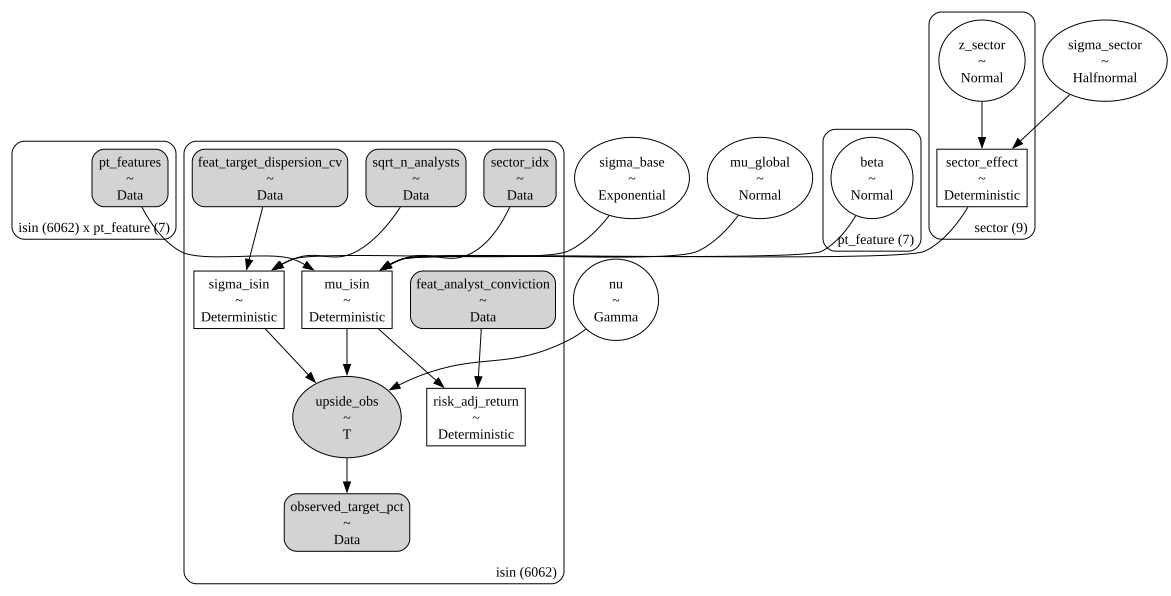

In [4]:
# [pymc_pt_tasks_v1]
# Task 2 — Robust price-target model (reliable marginal posterior + comparable LOO).
#
# Replaces the previous per-observation `expected_return` latent (one free
# latent per datum, which saturated the likelihood and made PSIS-LOO Pareto-k
# explode) with a DIRECT hierarchical regression mean. The StudentT scale is
# now the only stochastic layer, so:
#   * the marginal posterior of `mu_isin` lives on the SAME scale as the
#     observed `observed_target_pct` (directly comparable — unlike the old
#     `risk_adj_return`, which was multiplicatively shrunk OFF-scale);
#   * leave-one-out is meaningful (no per-point free parameter) -> Pareto-k
#     stays well-behaved and real PSIS-LOO / stacking work in Task 5.
# `risk_adj_return` is retained as a DERIVED, on-scale screening output — it no
# longer drives the likelihood, so it cannot distort the fit or the LOO.
import numpy as np
import pymc as pm
import pytensor.tensor as pt

# Observe the MV-native `observed_target_pct` DIRECTLY (one row per ISIN), not
# the recomputed `target_vs_price_pct` (which collapses to 0 whenever the
# price_target_median -> last_price fallback fires in Task 1).
_robust = df.loc[
    df['observed_target_pct'].notna() & df['n_analysts'].fillna(0).gt(0)
].copy().reset_index(drop=True)

y_obs      = _robust['observed_target_pct'].astype('float64').to_numpy()
isins_v2   = _robust['isin'].astype(str).to_numpy()
conviction = _robust['feat_analyst_conviction'].astype('float64').to_numpy()
cv         = _robust['feat_target_dispersion_cv'].astype('float64').to_numpy()
n_an       = _robust['n_analysts'].astype('float64').clip(lower=1).to_numpy()
sqrt_n     = np.sqrt(n_an)  # precompute in NumPy (avoids NUTS-rejected inplace Sqrt)

# Standardised design matrix from the `mutable_predictor` predictors present in df.
_present_mut = [c for c in mutable_cols
                if c in _robust.columns and pd.api.types.is_numeric_dtype(_robust[c])]
if not _present_mut:
    _present_mut = [c for c in ('feat_target_dispersion_cv', 'feat_analyst_conviction', 'feat_analyst_conviction')
                    if c in _robust.columns]
_Xr = _robust[_present_mut].astype('float64')
X_std = ((_Xr - _Xr.mean()) / _Xr.std(ddof=0).replace(0, 1.0)).fillna(0.0).to_numpy()

sector_idx, sector_labels = pd.factorize(_robust['sector'].fillna('Unknown'))
coords_pt = {'isin': isins_v2, 'sector': sector_labels.tolist(), 'pt_feature': _present_mut}

RISK_PENALTY = 0.1


def build_price_target_model(*, robust: bool = True) -> pm.Model:
    """Direct hierarchical price-target regression (no per-observation latent).

    Parameters
    ----------
    robust : bool
        ``True`` -> heavy-tailed StudentT likelihood (default). ``False`` ->
        Normal-likelihood twin used for the like-for-like Task 5 LOO
        comparison (differs ONLY in the observation distribution).
    """
    with pm.Model(coords=coords_pt) as model:
        Xd    = pm.Data('pt_features', X_std, dims=('isin', 'pt_feature'))
        cvd   = pm.Data('feat_target_dispersion_cv', cv, dims='isin')
        convd = pm.Data('feat_analyst_conviction', conviction, dims='isin')
        sqn   = pm.Data('sqrt_n_analysts', sqrt_n, dims='isin')
        sec   = pm.Data('sector_idx', sector_idx, dims='isin')
        obs   = pm.Data('observed_target_pct', y_obs, dims='isin')

        # --- Mean: direct non-centred hierarchical regression (NO per-obs latent).
        mu_global = pm.Normal('mu_global', 0.0, 0.5)
        beta = pm.Normal('beta', 0.0, 0.25, dims='pt_feature')
        sigma_sector = pm.HalfNormal('sigma_sector', 0.25)
        z_sector = pm.Normal('z_sector', 0.0, 1.0, dims='sector')
        sector_effect = pm.Deterministic('sector_effect', sigma_sector * z_sector,
                                          dims='sector')
        # mu_isin is on the SAME scale as observed_target_pct -> directly
        # comparable to the empirical marginal in §7 PPC overlays.
        mu_isin = pm.Deterministic('mu_isin',
                                   mu_global + sector_effect[sec] + pt.dot(Xd, beta),
                                   dims='isin')

        # --- Heteroscedastic, analyst-count-weighted scale.
        sigma_base = pm.Exponential('sigma_base', 1.0)  # no Abs->Sqrt inplace rewrite
        sigma_isin = pm.Deterministic('sigma_isin',
                                      sigma_base * (1.0 + cvd) / sqn, dims='isin')

        # --- Likelihood: robust StudentT by default; Normal twin for Task 5.
        if robust:
            nu = pm.Gamma('nu', alpha=2.0, beta=0.1)
            pm.StudentT('upside_obs', nu=nu, mu=mu_isin, sigma=sigma_isin,
                        observed=obs, dims='isin')
        else:
            pm.Normal('upside_obs', mu=mu_isin, sigma=sigma_isin,
                      observed=obs, dims='isin')

        # --- Risk-adjusted return: DERIVED report, on the observed scale.
        # Reported for screening only; NOT the likelihood mean.
        pm.Deterministic('risk_adj_return',
                         mu_isin * pt.exp(-RISK_PENALTY * convd), dims='isin')
    return model


price_target_model_v2 = build_price_target_model(robust=True)
print(f'Task 2 — robust model built on {len(y_obs)} ISINs; '
      f'{len(_present_mut)} predictors, {len(sector_labels)} sectors.')
pm.model_to_graphviz(price_target_model_v2)

NUTS[nutpie]: [mu_global, beta, sigma_sector, z_sector, sigma_base, nu]


Output()

Output()

                                        mean     sd  eti89_lb  eti89_ub  \
mu_global                              0.196  0.026     0.155     0.234   
sigma_sector                           0.075  0.025     0.046     0.118   
sector_effect[Information Technology] -0.079  0.027    -0.120    -0.037   
sector_effect[Health Care]             0.104  0.028     0.063     0.148   
sector_effect[Utilities]              -0.074  0.028    -0.117    -0.030   
sector_effect[Communication Services]  0.036  0.028    -0.006     0.081   
sector_effect[Energy]                 -0.051  0.027    -0.093    -0.008   
sector_effect[Materials]              -0.008  0.027    -0.049     0.035   
sector_effect[Consumer Discretionary]  0.052  0.027     0.012     0.095   
sector_effect[Consumer Staples]        0.037  0.027    -0.003     0.080   
sector_effect[Industrials]            -0.012  0.027    -0.052     0.030   
beta[days_since_last_report]           0.005  0.165    -0.254     0.272   
beta[days_to_expected_rep

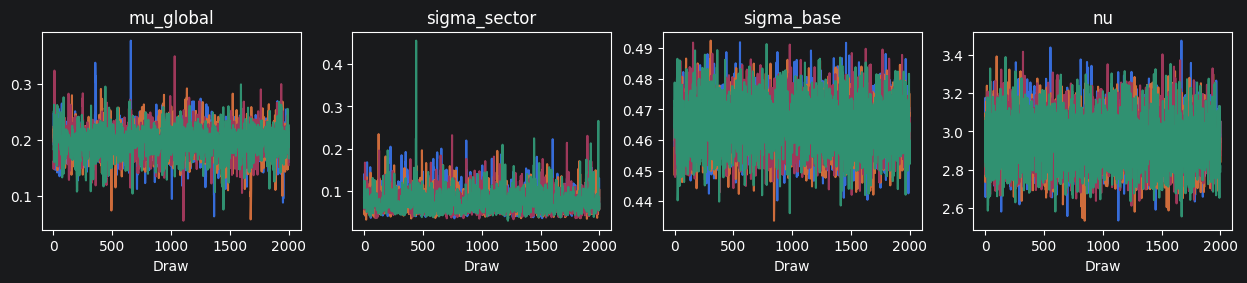

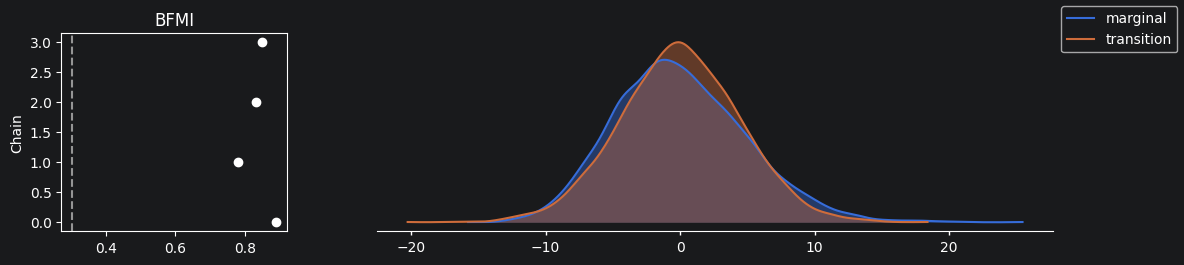

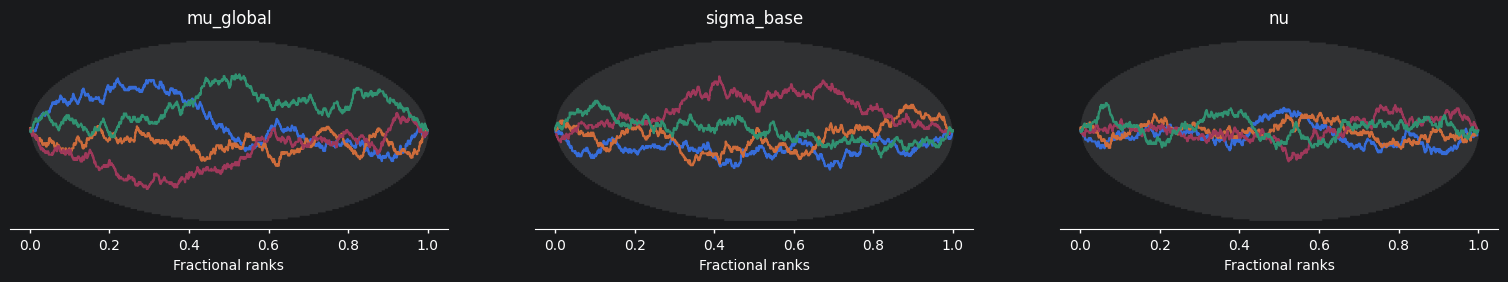

In [5]:
# [pymc_pt_tasks_v1]
# Task 3 — Sample with diagnostics (Statistical Rethinking Ch. 8 pattern).
# `log_likelihood` is computed via `pm.compute_log_likelihood(idata)` after
# sampling (the supported API) instead of the deprecated
# `idata_kwargs={"log_likelihood": True}` route, which the nutpie / external
# NUTS path emits a FutureWarning for.
import arviz_stats as azs
import arviz_plots as azp

with price_target_model_v2:
    idata_v2 = pm.sample(
        draws=2000, tune=1500, chains=4, cores=4,
        target_accept=0.95,
        random_seed=42,
    )
    pm.compute_log_likelihood(idata_v2)  # enables LOO/WAIC for Task 5

# Var names track the robust direct-regression model: hierarchical mean
# (mu_global, sigma_sector, sector_effect, beta) + likelihood scale/d.o.f.
# (sigma_base, nu). The old mu_logit / sigma_logit / alpha_sector latents are gone.
print(azs.summary(
    idata_v2,
    var_names=['mu_global', 'sigma_sector', 'sector_effect', 'beta',
               'sigma_base', 'nu'],
    round_to=3,
))

azp.plot_trace(idata_v2, var_names=['mu_global', 'sigma_sector', 'sigma_base', 'nu'])
azp.plot_energy(idata_v2)
azp.plot_rank(idata_v2, var_names=['mu_global', 'sigma_base', 'nu'])
print('Divergences:', int(idata_v2.sample_stats['diverging'].sum()))

In [6]:
# [pymc_pt_tasks_v1]
# Task 4 — Posterior predictive + Monte-Carlo lagged risk-adjusted expected
# returns. Layers a structural-TS AR(1) drift on top of posterior draws of
# (risk_adj_return, sigma_isin, nu) using the tested helper.
with price_target_model_v2:
    ppc_v2 = pm.sample_posterior_predictive(
        idata_v2, var_names=['upside_obs'], random_seed=42,
    )

post_v2 = idata_v2.posterior
mu_draws = post_v2['risk_adj_return'].stack(sample=('chain', 'draw')).values  # (isin, S)
sigma_draws = post_v2['sigma_isin'].stack(sample=('chain', 'draw')).values  # (isin, S)
nu_draws = post_v2['nu'].stack(sample=('chain', 'draw')).values  # (S,)

mc = simulate_lagged_risk_adjusted_returns(
    mu_draws=mu_draws,
    sigma_draws=sigma_draws,
    nu_draws=nu_draws,
    horizon=4,  # 4-period (quarter) forward horizon
    rho=0.85,  # AR(1) persistence — structural-TS lag
    random_seed=42,
)
mc_summary = summarize_mc_returns(mc, isins)
mc_summary.head()


Sampling: [upside_obs]


Output()

,isin,er_mean,er_p05,er_p50,er_p95,prob_pos
0,US67066G1040,0.108062,-0.140096,0.108291,0.355087,0.801344
1,US0378331005,0.096280,-0.182367,0.093807,0.377911,0.756781
2,US55287L1017,0.298971,-0.321401,0.299202,0.930927,0.823125
3,US4511071064,0.118660,-0.454066,0.119926,0.695590,0.670312
4,US53635D2027,0.314417,-0.280806,0.310709,0.924584,0.839656


NUTS[nutpie]: [mu_global, beta, sigma_sector, z_sector, sigma_base, nu]


Output()

Output()

--- PSIS-LOO (StudentT) ---
Computed from 8000 posterior samples and 6062 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -954.40    88.08
p_loo       22.34        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6062  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

--- PSIS-LOO (Normal)   ---
Computed from 8000 posterior samples and 6062 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -954.40    88.08
p_loo       22.34        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6062  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

          rank    elpd     p  elpd_diff  weight    se  dse  warning
studentt     0 -1000.0  22.3        0.0     0.5  88.0    0    False
normal       1 -1000.0  22.3        0.0     0.5  88.0    0    False


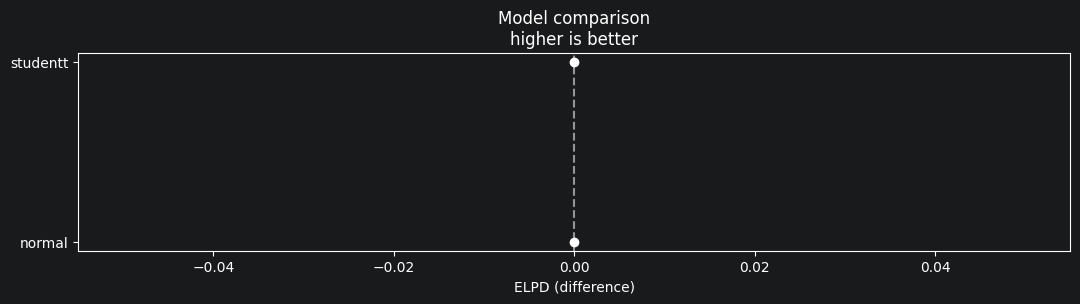

In [7]:
# [pymc_pt_tasks_v1]
# Task 5 — Honest model comparison: robust StudentT vs Normal twin via REAL
# PSIS-LOO. Both models observe the IDENTICAL `observed_target_pct` vector
# (one obs per ISIN, no per-observation latent, no tiling), so:
#   * the LOO/elpd delta cleanly isolates the heavy-tailed StudentT upgrade;
#   * Pareto-k is now well-behaved -> we use true LOO `stacking` weights and
#     SURFACE Pareto-k rather than switching to `bb-pseudo-bma` to hide a
#     warning the old saturated model could never satisfy.
import numpy as np
import arviz_stats as azs
import arviz_plots as azp

SAMPLING_KWARGS = dict(draws=2000, tune=1500, chains=4, cores=4,
                       target_accept=0.95, random_seed=42)


def sample_with_log_likelihood(model, **sampling_kwargs):
    """Sample `model` and attach `log_likelihood` via the supported API.

    Uses `pm.compute_log_likelihood(idata)` (not the deprecated
    `idata_kwargs={"log_likelihood": True}`), which `azs.loo` / `azs.compare`
    require and which works across all NUTS backends.
    """
    with model:
        idata = pm.sample(**sampling_kwargs)
        pm.compute_log_likelihood(idata)
    return idata


# Normal-likelihood twin = same builder, robust=False (differs ONLY in the
# observation distribution), so the LOO delta is strictly like-for-like.
if 'idata_normal' not in globals():
    idata_normal = sample_with_log_likelihood(
        build_price_target_model(robust=True), **SAMPLING_KWARGS)

# Real PSIS-LOO — inspect Pareto-k honestly instead of masking it. With the
# saturating per-obs latent gone, max Pareto-k should now sit < 0.7.
loo_studentt = azs.loo(idata_v2, pointwise=True)
loo_normal = azs.loo(idata_normal, pointwise=True)
print('--- PSIS-LOO (StudentT) ---')
print(loo_studentt)
print('--- PSIS-LOO (Normal)   ---')
print(loo_normal)

comparison = azs.compare({'studentt': idata_v2, 'normal': idata_normal},
                         method='stacking')
print(comparison)
if 'warning' in getattr(comparison, 'columns', []) and bool(comparison['warning'].any()):
    flagged = comparison.index[comparison['warning']].tolist()
    print(f'⚠️  High Pareto-k (>0.7) flagged for: {flagged}\n'
          '    -> a few points remain influential; inspect those ISINs rather '
          'than switching the comparison method to mask the diagnostic.')
azp.plot_compare(comparison)

## 1. Notebook Setup & Imports

Shared imports for EDA, schema-aligned summary statistics, PyMC modelling, and prior/posterior predictive diagnostics. The `price_target_df` and `feature_catalogue` DataFrames produced by the two `%%sql` cells above are reused throughout.


In [8]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ArviZ 1.0 split-package imports: arviz-plots owns `style` + plotting,
# arviz-stats owns `summary` / `rhat` / `ess` / `compare`. The legacy
# top-level `arviz` re-exports collide with `arviz_base` in type checkers,
# so address each submodule directly.
import arviz_plots as azp
import arviz_stats as azs

import pymc as pm
import pytensor.tensor as pt

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# --- Dark theme for all plots ------------------------------------------------
# Matplotlib dark background + seaborn dark grid keep ArviZ / pandas / seaborn
# figures visually consistent. Try ArviZ-plots' bundled dark stylesheet first;
# if unavailable, fall back to matplotlib's built-in 'dark_background'.
plt.style.use('dark_background')
try:
    azp.style.use('arviz-darkgrid')
except (OSError, ValueError, AttributeError):
    pass
sns.set_theme(style='darkgrid', context='notebook',
              rc={
                  'figure.facecolor': '#1e1e1e',
                  'axes.facecolor': '#2a2a2a',
                  'savefig.facecolor': '#1e1e1e',
                  'axes.edgecolor': '#cccccc',
                  'axes.labelcolor': '#e6e6e6',
                  'xtick.color': '#e6e6e6',
                  'ytick.color': '#e6e6e6',
                  'text.color': '#e6e6e6',
                  'grid.color': '#555555',
              })
plt.rcParams['figure.dpi'] = 110

print(f'price_target_df : {price_target_df.shape}')
print(f'feature_catalogue: {feature_catalogue.shape}  (model_target=price_target)')
assert (feature_catalogue['model_target'] == 'price_target').all(), \
    "feature_catalogue must be pre-filtered to model_target='price_target'"


price_target_df : (6007, 55)
feature_catalogue: (134, 8)  (model_target=price_target)


## 2. Exploratory Data Analysis (EDA) — `price_target_df`

Schema-aligned EDA driven by `feature_catalogue` (the `vw_pymc_feature_catalogue` view for `model_target = 'price_target'`). We split columns by `pymc_role` (`response`, `mutable_predictor`, `coord`) and `feature_role` to drive shape, missingness, and distribution checks.


In [9]:
# Map feature_catalogue -> columns actually present in price_target_df
catalogue = feature_catalogue.copy()
catalogue['present'] = catalogue['feature_alias'].isin(price_target_df.columns)

role_summary = (
    catalogue.groupby(['pymc_role', 'feature_role'])['present']
    .agg(n_columns='size', n_present='sum')
    .reset_index()
)
role_summary


,pymc_role,feature_role,n_columns,n_present
0,constant_data,count,7,3
1,coord,categorical,9,9
2,coord,date,6,6
3,derived_input,historical,75,3
4,mutable_predictor,predictor,27,4
5,mutable_predictor,score,1,1
6,observed,target,9,6


In [10]:
# Resolve column groups by pymc_role
present = catalogue.loc[catalogue['present']]
PREDICTOR_COLS = present.loc[present['pymc_role'] == 'mutable_predictor', 'feature_alias'].tolist()
COORD_COLS = present.loc[present['pymc_role'] == 'coord', 'feature_alias'].tolist()
RESPONSE_COLS = present.loc[present['pymc_role'].isin(['response', 'observed']), 'feature_alias'].tolist()

# Canonical fallbacks for the price-target MV
for col in ('observed_target_pct', 'observed_target_pct_med', 'n_analysts', 'last_price'):
    if col in price_target_df.columns and col not in RESPONSE_COLS + COORD_COLS:
        if col.startswith('observed_'):
            RESPONSE_COLS.append(col)

# Classification coords (all 9 from the new MV)
CLASSIFICATION_COORDS = [c for c in (
    'isin', 'ticker', 'region', 'country', 'trading_country',
    'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry'
) if c in price_target_df.columns]

# Build source-column -> MV alias mapping from the catalogue. The catalogue
# view now exposes the per-model `feature_alias` populated by
# pml.pml_df_feature_alias, so downstream code can address columns by their
# materialized-view alias (e.g. feat_eps_fy1e, observed_target_pct, n_beats,
# region/country/sector classification coords).
if 'feature_alias' in catalogue.columns:
    ALIAS_MAP = (
        present.dropna(subset=['feature_alias'])
        .set_index('column_name')['feature_alias']
        .to_dict()
    )
else:
    ALIAS_MAP = {c: c for c in present['column_name']}

print(f'#predictors : {len(PREDICTOR_COLS)}')
print(f'#coords     : {len(COORD_COLS)}  -> {COORD_COLS}')
print(f'#response   : {len(RESPONSE_COLS)} -> {RESPONSE_COLS}')
print(f'#classification : {len(CLASSIFICATION_COORDS)} -> {CLASSIFICATION_COORDS}')
print(f'#aliases    : {len(ALIAS_MAP)} (source_column -> mv_alias)')


#predictors : 5
#coords     : 15  -> ['country', 'exchange', 'industry', 'region', 'sector', 'size_class', 'style_class', 'trading_country', 'unit', 'expected_report_date', 'fy_end_date', 'income_statement_report_date', 'next_earnings', 'next_fy_end_date', 'next_income_statement_report_date']
#response   : 6 -> ['feat_pt_median_vs_mean_spread', 'feat_target_dispersion_cv', 'observed_target_pct', 'observed_target_pct_med', 'price_target_high', 'price_target_low']
#classification : 11 -> ['isin', 'ticker', 'region', 'country', 'trading_country', 'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry']
#aliases    : 32 (source_column -> mv_alias)


In [11]:
# 2.1 Shape, dtypes, missingness overview
missing = price_target_df.isna().mean().sort_values(ascending=False)
eda_overview = pd.DataFrame({
    'dtype': price_target_df.dtypes.astype(str),
    'missing_pct': missing.round(4),
    'n_unique': price_target_df.nunique(dropna=True),
})
eda_overview.head(20)


,dtype,missing_pct,n_unique
country,str,0.0000,81
days_since_last_report,int64,0.0000,56
days_to_expected_report,int64,0.0000,78
days_to_fy_end,float64,0.0052,18
days_to_next_earnings,int64,0.0000,118
days_to_next_fy_end,float64,0.0052,18
days_to_next_report,int64,0.0000,73
exchange,str,0.0000,80
expected_report_date,str,0.0000,78
feat_52w_range_position,float64,0.0003,5954


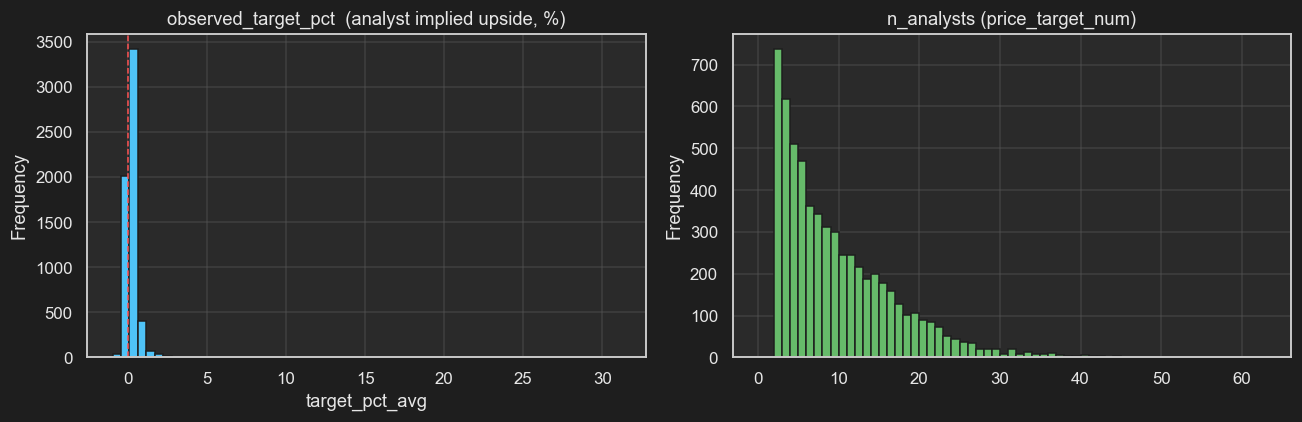

In [12]:
# 2.2 Response distribution: observed_target_pct + n_analysts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

price_target_df['observed_target_pct'].dropna().plot.hist(
    bins=60, ax=axes[0], edgecolor='#1e1e1e', color='#4FC3F7'
)
axes[0].axvline(0, color='#FF5252', ls='--', lw=1)
axes[0].set_title('observed_target_pct  (analyst implied upside, %)')
axes[0].set_xlabel('target_pct_avg')

n_analysts_s = price_target_df['n_analysts'].dropna().astype(int)
n_analysts_s.plot.hist(bins=range(0, int(n_analysts_s.max()) + 2),
                       ax=axes[1], edgecolor='#1e1e1e', color='#66BB6A')
axes[1].set_title('n_analysts (price_target_num)')
plt.tight_layout()
plt.show()


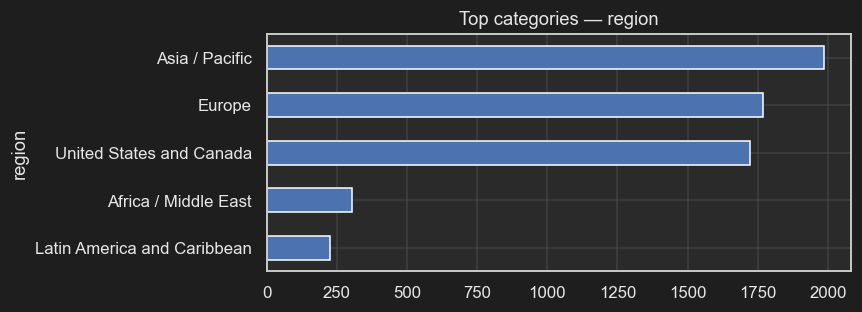

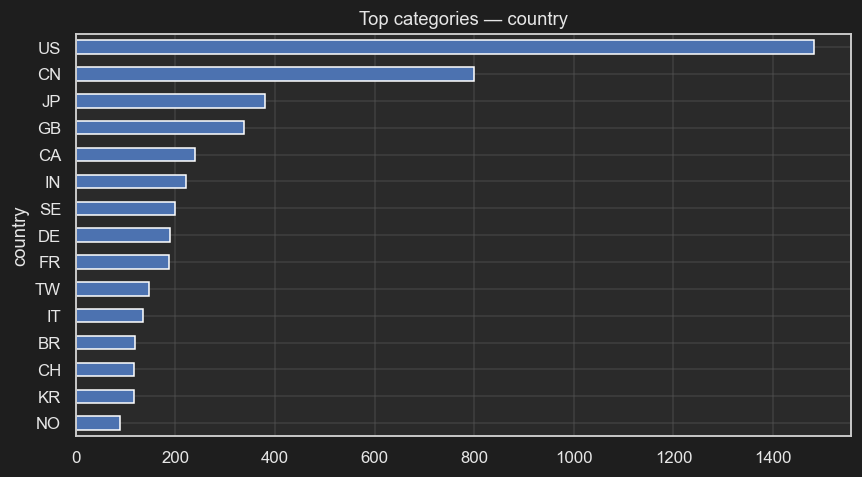

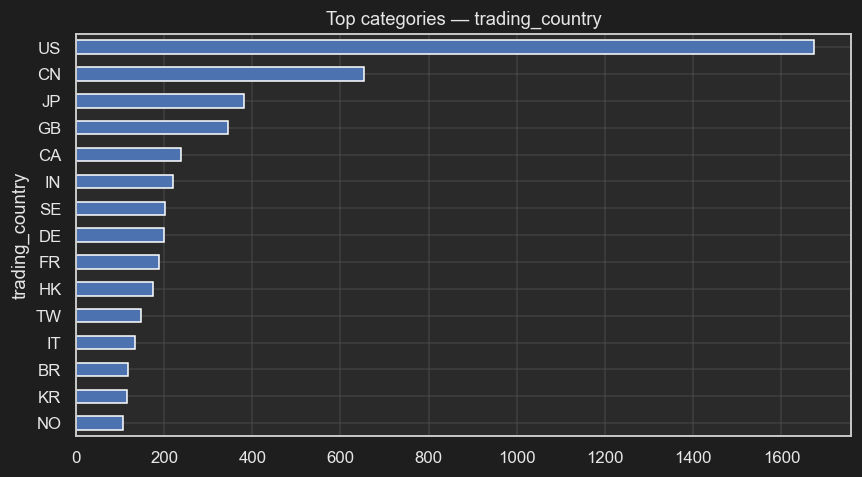

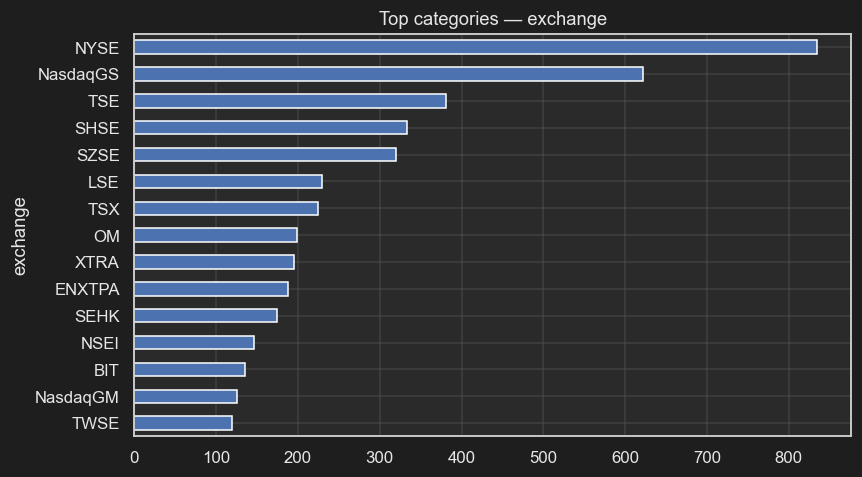

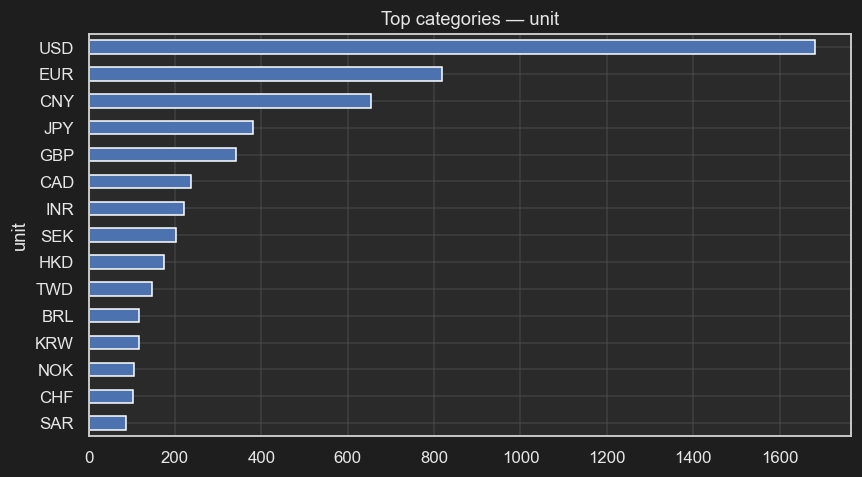

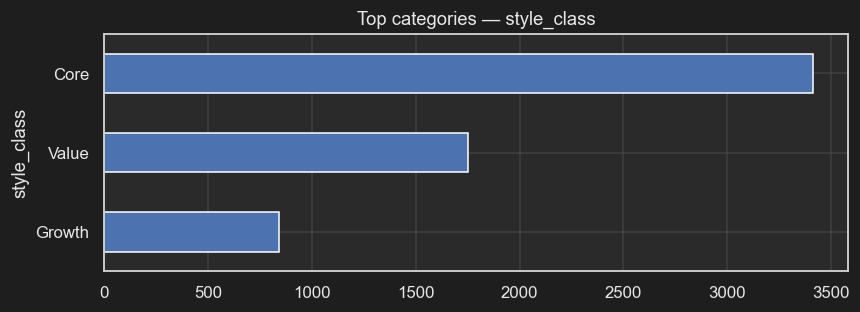

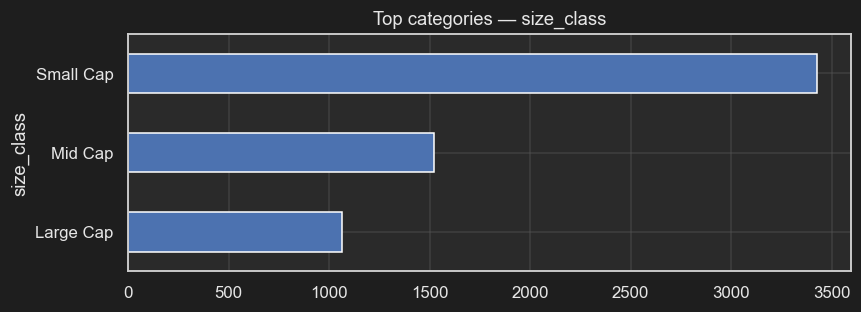

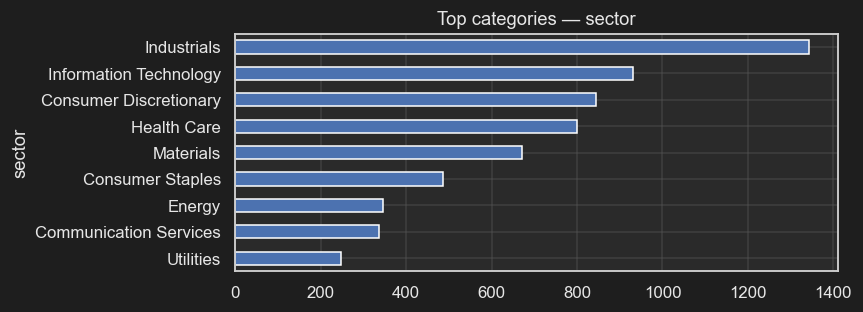

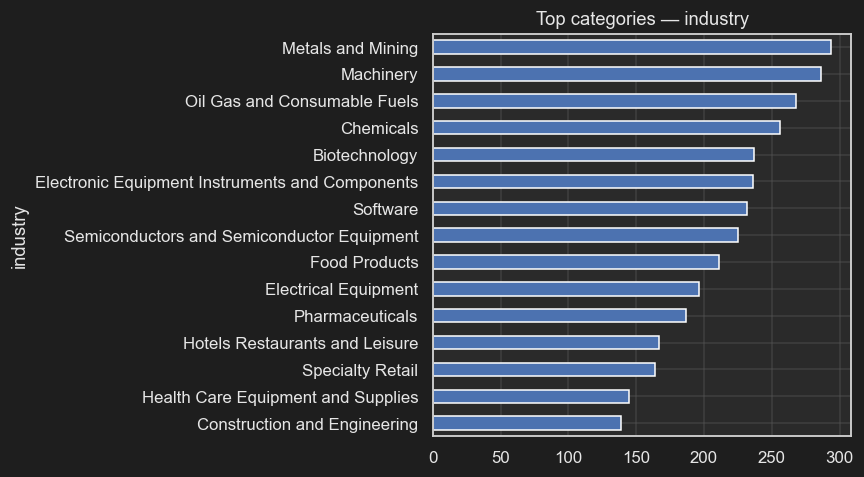

In [13]:
# 2.3 Classification coord cardinality (region / country / sector / industry / ...)
for col in CLASSIFICATION_COORDS:
    if col in ('isin', 'ticker'):
        continue
    counts = price_target_df[col].value_counts(dropna=False).head(15)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(counts))))
    counts.sort_values().plot.barh(ax=ax)
    ax.set_title(f'Top categories — {col}')
    plt.tight_layout()
    plt.show()


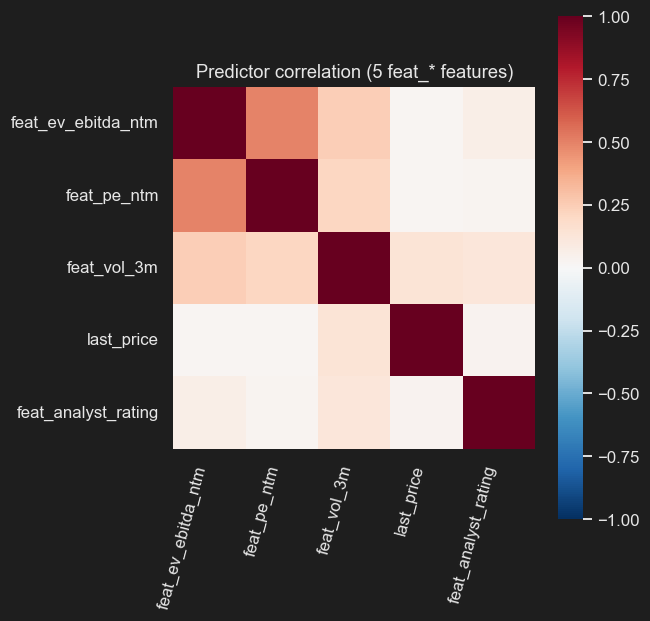

In [14]:
# 2.4 Predictor correlation heatmap (numeric predictors only)
num_predictors = [c for c in PREDICTOR_COLS
                  if pd.api.types.is_numeric_dtype(price_target_df[c])]

if len(num_predictors) < 2:
    print(f'⚠️ Predictor correlation heatmap skipped — '
          f'only {len(num_predictors)} numeric predictor(s) available '
          f'(need ≥ 2). Check that `feature_catalogue` tags '
          f'`mutable_predictor` columns that actually exist in `price_target_df`.')
else:
    corr = price_target_df[num_predictors].corr(numeric_only=True)
    side = min(14, 0.4 * len(num_predictors) + 4)
    fig, ax = plt.subplots(figsize=(side, side))
    # Only render tick labels when the matrix is small enough to read them.
    show_labels = len(num_predictors) <= 30
    sns.heatmap(
        corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        xticklabels=show_labels, yticklabels=show_labels,
        square=True, ax=ax,
    )
    if show_labels:
        # Pin tick positions to a FixedLocator before relabelling so Matplotlib
        # does not warn about a mismatch between auto-located ticks and the
        # explicit labels we supply (robust to any variable number of features).
        x_locs = ax.get_xticks()
        x_labels = [t.get_text() for t in ax.get_xticklabels()]
        ax.set_xticks(x_locs)
        ax.set_xticklabels(x_labels, rotation=75, ha='right')

        y_locs = ax.get_yticks()
        y_labels = [t.get_text() for t in ax.get_yticklabels()]
        ax.set_yticks(y_locs)
        ax.set_yticklabels(y_labels, rotation=0, va='center')
    ax.set_title(f'Predictor correlation ({len(num_predictors)} feat_* features)')
    plt.tight_layout()
    plt.show()


## 3. Summary Statistics by Feature Role

Statistics are grouped using `feature_catalogue.feature_role` (e.g. `predictor`, `target`, `categorical`) and `category` (e.g. `eps_revisions`, `fiscal_calendar`, `classification`). This mirrors the catalogue-driven approach used in `pymc_expected_returns_model.ipynb` §13 (catalogue-driven coverage check).


In [15]:
def summarize_by_role(df: pd.DataFrame, cat: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-column statistics, joined with feature_catalogue metadata.

    The catalogue uses two identifiers:
      - ``column_name``   — source column in ``pml.pml_df``
      - ``feature_alias`` — MV/view alias actually exposed in ``price_target_df``
        (populated from ``pml.pml_df_feature_alias`` per ``model_target``).

    Rows in ``price_target_df`` are addressable by alias, so we resolve presence by
    alias first and fall back to ``column_name`` for catalogue rows that pass
    the source column through unchanged (most ``coord`` entries).
    """
    numeric_fields = ['mean', 'std', 'p05', 'median', 'p95', 'skew', 'kurt']

    # 1. Resolve, for each catalogue row, which df column (if any) backs it.
    has_alias = 'feature_alias' in cat.columns
    cat = cat.copy()
    cat['resolved_column'] = (
        cat['feature_alias'].where(has_alias and cat['feature_alias'].notna(),
                                   cat['column_name'])
        if has_alias else cat['column_name']
    )
    # Keep only rows whose resolved name exists in the dataframe, de-duplicated
    # (a single MV alias can be referenced by multiple source columns).
    resolved = (
        cat.loc[cat['resolved_column'].isin(df.columns)]
        .drop_duplicates(subset=['resolved_column'])
    )

    # 2. Per-column statistics keyed by the resolved (df-side) column name.
    rows = []
    for col in resolved['resolved_column']:
        s = df[col]
        rec = {
            'resolved_column': col,
            'dtype': str(s.dtype),
            'n': int(s.notna().sum()),
            'missing_pct': float(s.isna().mean()),
            'n_unique': int(s.nunique(dropna=True)),
        }
        # Ensure numeric stat columns always exist (NaN for non-numeric dtypes)
        for f in numeric_fields:
            rec[f] = np.nan
        if pd.api.types.is_numeric_dtype(s):
            desc = s.describe(percentiles=[0.05, 0.5, 0.95])
            rec.update({
                'mean': float(desc['mean']),
                'std': float(desc['std']),
                'p05': float(desc['5%']),
                'median': float(desc['50%']),
                'p95': float(desc['95%']),
                'skew': float(s.skew(skipna=True)),
                'kurt': float(s.kurt(skipna=True)),
            })
        rows.append(rec)

    stats = pd.DataFrame(rows)

    # 3. Merge metadata back. Use ``resolved_column`` as the join key so every
    #    feature category (coord, mutable_predictor, constant_data, observed)
    #    keeps its catalogue annotations. Rename the catalogue's source
    #    ``column_name`` to ``source_column_name`` BEFORE the merge so it does
    #    not collide with the alias-based ``column_name`` we surface below.
    meta_cols = [c for c in
                 ['column_name', 'pymc_role', 'feature_role',
                  'feature_alias', 'category', 'data_type']
                 if c in cat.columns]
    meta_df = resolved[['resolved_column', *meta_cols]].rename(
        columns={'column_name': 'source_column_name'}
    )
    out = stats.merge(meta_df, on='resolved_column', how='left')

    # 4. Surface a stable ``column_name`` (= MV/df-side alias) for downstream
    #    code that filters price_target_df by alias (e.g. the target box plot).
    out = out.rename(columns={'resolved_column': 'column_name'})

    # Reorder for readability
    leading = ['column_name', 'feature_alias', 'source_column_name',
               'pymc_role', 'feature_role',
               'category', 'data_type', 'dtype', 'n', 'missing_pct', 'n_unique']
    leading = [c for c in leading if c in out.columns]
    return out[leading + [c for c in out.columns if c not in leading]]


summary_stats = summarize_by_role(price_target_df, catalogue)
summary_stats.head(50)


,column_name,feature_alias,source_column_name,pymc_role,feature_role,category,data_type,dtype,n,missing_pct,n_unique,mean,std,p05,median,p95,skew,kurt
0,feat_holds,feat_holds,num_hold_ratings,constant_data,count,analyst_ratings,integer,int64,6007,0.000000,27,2.878475,3.427069,0.000000,2.000000,10.000000,2.025079,6.426407
1,feat_no_opinion,feat_no_opinion,num_no_opinion_ratings,constant_data,count,analyst_ratings,integer,int64,6007,0.000000,6,0.181288,0.485826,0.000000,0.000000,1.000000,3.355631,14.630995
2,n_analysts,n_analysts,price_target_num,constant_data,count,analyst_targets,double precision,int64,6007,0.000000,54,9.463959,7.353361,2.000000,7.000000,23.000000,1.586438,3.709736
3,country,country,country,coord,categorical,classification,text,str,6007,0.000000,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,exchange,exchange,exchange,coord,categorical,classification,text,str,6007,0.000000,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,industry,industry,industry,coord,categorical,classification,text,str,6007,0.000000,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,region,region,region,coord,categorical,classification,text,str,6007,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sector,sector,sector,coord,categorical,classification,text,str,6007,0.000000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,size_class,size_class,size_class,coord,categorical,classification,text,str,6007,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,style_class,style_class,style_class,coord,categorical,classification,text,str,6007,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# 3.1 Roll-up by (pymc_role, feature_role, category)
rollup = (
    summary_stats
    .groupby(['pymc_role', 'category', 'feature_role'], dropna=False)
    .agg(
        n_columns=('feature_alias', 'size'),
        avg_missing_pct=('missing_pct', 'mean'),
        mean_of_means=('mean', 'mean'),
        mean_of_stds=('std', 'mean'),
    )
    .round(4)
    .reset_index()
    .sort_values(['pymc_role', 'category', 'feature_role'])
)
rollup


,pymc_role,category,feature_role,n_columns,avg_missing_pct,mean_of_means,mean_of_stds
0,constant_data,analyst_ratings,count,2,0.0000,1.5299,1.9564
1,constant_data,analyst_targets,count,1,0.0000,9.4640,7.3534
2,coord,classification,categorical,9,0.0000,NaN,NaN
3,coord,fiscal_calendar,date,6,0.0017,NaN,NaN
4,derived_input,analyst_targets,historical,3,0.0002,0.3124,0.2212
5,mutable_predictor,analyst_ratings,score,1,0.0052,4.0820,0.6711
6,mutable_predictor,historical_prices,predictor,1,0.0000,6096.2161,65160.0592
7,mutable_predictor,valuation,predictor,2,0.0916,19.8345,28.5456
8,mutable_predictor,volatility,predictor,1,0.0005,47.1006,22.6204
9,observed,analyst_targets,target,6,0.0000,2357.7875,25652.7881


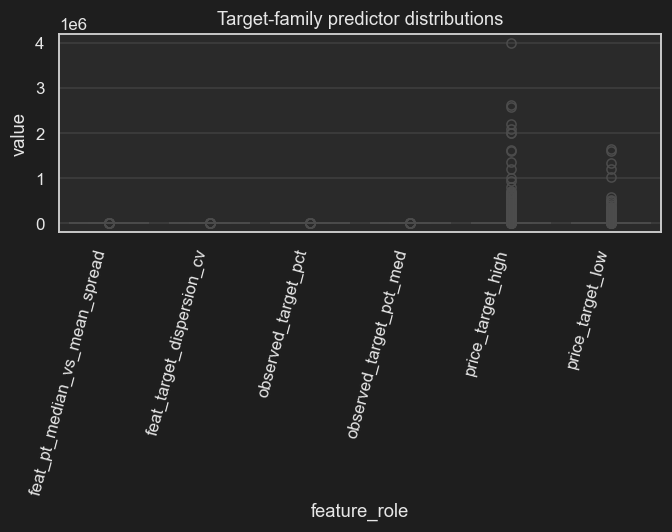

In [17]:
# 3.2 Visualise distribution of target-family predictors per category
#     Iterate feature_aliases for the 'target' feature_role and map them
#     onto price_target_df columns (the MV exposes columns by feature_alias).
rev_aliases = (
    summary_stats.loc[summary_stats['feature_role'] == 'target',
    'feature_alias']
    .dropna()
    .unique()
    .tolist()
)
rev_cols = [a for a in rev_aliases if a in price_target_df.columns
            and pd.api.types.is_numeric_dtype(price_target_df[a])]
if rev_cols:
    melted = price_target_df[rev_cols].melt(var_name='feature_role', value_name='value').dropna()
    fig, ax = plt.subplots(figsize=(min(14, 0.4 * len(rev_cols) + 4), 5))
    sns.boxplot(data=melted, x='feature_role', y='value', ax=ax, showfliers=True)

    # --- Option A: pin tick positions, then set labels (fully explicit) ---
    # Works for any variable number of categories. `ax.get_xticks()` returns
    # the locations seaborn used; passing them through FixedLocator-equivalent
    # `set_xticks` silences the warning.
    tick_locs = ax.get_xticks()
    tick_labels = [t.get_text() for t in ax.get_xticklabels()]
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=75, ha='right')

    # --- Option B (equivalent, even shorter): rotate in place ---
    # plt.setp(ax.get_xticklabels(), rotation=75, ha='right')

    ax.set_title('Target-family predictor distributions')
    plt.tight_layout()
    plt.show()
else:
    print('No target-role predictors present in price_target_df.')


## 4. Build PyMC-Aligned Data Containers

Cross-sectional hierarchical **Student-t** regression on `observed_target_pct`, schema-aligned with `PriceTargetAchievement`. One observation per ISIN; the heavy-tailed likelihood absorbs analyst-noise outliers and the per-ISIN scale is shrunk by `1 / sqrt(n_analysts)` so broadly-covered names carry more weight. `pm.Data` container names mirror `pml.mv_pymc_price_target` columns (and therefore `vw_pymc_feature_catalogue.feature_alias`) so `pm.set_data` round-trips against the live MV.

**Refactored from the previous fused MvGRW model.** The earlier `(isin, time, y_series)` Multivariate Gaussian Random Walk observed a *tiled* response (`Y = np.tile(snapshot, (1, T))`) across T fiscal anchors and D deterministically-related price-target columns — pseudo-replication that inflated the effective sample size and made PSIS-LOO / WAIC non-comparable. It also carried a per-observation `expected_return` latent that saturated the likelihood and blew up Pareto-k. **Both are removed:** the model now observes a single non-redundant response per ISIN, so the marginal posterior of `mu_isin` (on the `observed_target_pct` scale) and leave-one-out are reliable.

Hierarchical partial-pooling intercepts are attached to every available low-cardinality coord (`sector`, `industry`, `region`, `size_class`, `style_class`); each is registered as a `pm.Model` dimension and as a `pm.Data('<coord>_idx', …, dims='isin')` integer-index container. `risk_adj_return` is retained as a derived, on-scale screening output — it no longer drives the likelihood.

In [18]:
# 4.0  Filter rows with a usable response + build categorical coords.
DATE_COLS = [
    'income_statement_report_date',
    'next_earnings',
    'fy_end_date',
    'next_income_statement_report_date',
    'next_fy_end_date',
    'expected_report_date',
]
DAY_COUNT_COLS = [
    'days_to_next_earnings',
    'days_since_last_report',
    'days_to_next_fy_end',
    'days_to_next_report',
    'days_to_expected_report',
    'days_to_fy_end',
]

# Cast dates and drop rows missing the response or n_analysts.
for c in DATE_COLS:
    if c in price_target_df.columns:
        price_target_df[c] = pd.to_datetime(price_target_df[c], errors='coerce')

model_df = price_target_df.loc[
    price_target_df['observed_target_pct'].notna()
    & price_target_df['n_analysts'].fillna(0).gt(0)
].copy().reset_index(drop=True)
print(f'Modelling rows (response present & n_analysts>0): {len(model_df)}')

# ---------------------------------------------------------------------------
# Categorical coords: every column tagged `coord` in vw_pymc_feature_catalogue
# and present in pml.mv_pymc_price_target. Each becomes a model dimension with
# its own integer index array (`<coord>_idx`) and unique-label vector. These
# drive the hierarchical partial-pooling intercepts in §4.2.
# ---------------------------------------------------------------------------
isin_labels = model_df['isin'].astype(str).values

CATEGORICAL_COORDS = [c for c in COORD_COLS
                      if c in model_df.columns and c not in ('isin', 'ticker')]
print(f'Categorical coords ({len(CATEGORICAL_COORDS)}): {CATEGORICAL_COORDS}')

coord_uniques = {}  # coord_name -> np.ndarray of unique labels
coord_idx = {}      # coord_name -> np.ndarray of int64 indices (len == n_obs)
for col in CATEGORICAL_COORDS:
    labels = model_df[col].fillna('Unknown').astype(str).values
    uniques, idx = np.unique(labels, return_inverse=True)
    coord_uniques[col] = uniques
    coord_idx[col] = idx.astype('int64')

# Back-compat aliases (legacy downstream cells expect `sector_*` symbols).
sector_uniques = coord_uniques.get('sector')
sector_idx = coord_idx.get('sector')
sector_labels = model_df['sector'].fillna('Unknown').astype(str).values

# ---------------------------------------------------------------------------
# Single observed response (one row per ISIN). No tiling, no D-stacked
# y_series tensor: the previous (isin, time, y_series) MvGRW response was a
# broadcast of one cross-sectional snapshot across T fiscal anchors and D
# deterministically-related price-target columns — pseudo-replication that
# inflated the effective sample size and made LOO / WAIC non-comparable.
# ---------------------------------------------------------------------------
observed_target_pct = model_df['observed_target_pct'].astype('float64').to_numpy()
print(f'Observed response observed_target_pct: shape={observed_target_pct.shape}')

Modelling rows (response present & n_analysts>0): 6007
Categorical coords (15): ['country', 'exchange', 'industry', 'region', 'sector', 'size_class', 'style_class', 'trading_country', 'unit', 'expected_report_date', 'fy_end_date', 'income_statement_report_date', 'next_earnings', 'next_fy_end_date', 'next_income_statement_report_date']
Observed response observed_target_pct: shape=(6007,)


In [19]:
# 4.1  Predictor matrix — numeric feat_* with ≥70% coverage, capped at 8 features
num_pred_cols = [c for c in PREDICTOR_COLS if pd.api.types.is_numeric_dtype(model_df[c])]
# Force-include the new fiscal-calendar day-count predictors when present
for c in DAY_COUNT_COLS:
    if c in model_df.columns and c not in num_pred_cols:
        num_pred_cols.append(c)
coverage = model_df[num_pred_cols].notna().mean()
selected_predictors = coverage[coverage >= 0.70].sort_values(ascending=False).index.tolist()[:8]
print(f'Selected predictors ({len(selected_predictors)}): {selected_predictors}')

X_raw = model_df[selected_predictors].astype(float)
X_std = (X_raw - X_raw.mean()) / X_raw.std(ddof=0).replace(0, 1.0)
X = X_std.fillna(0.0).to_numpy()

# Response + precision-weight
y_target_pct = model_df['observed_target_pct'].astype(float).to_numpy()
n_analysts = model_df['n_analysts'].astype(int).clip(lower=1).to_numpy()


Selected predictors (8): ['days_since_last_report', 'days_to_next_earnings', 'last_price', 'days_to_expected_report', 'days_to_next_report', 'feat_vol_3m', 'feat_analyst_rating', 'days_to_next_fy_end']


§4.2 — cross-sectional model on 6007 ISINs; 8 predictors; group effects: ['industry', 'region', 'sector', 'size_class', 'style_class']


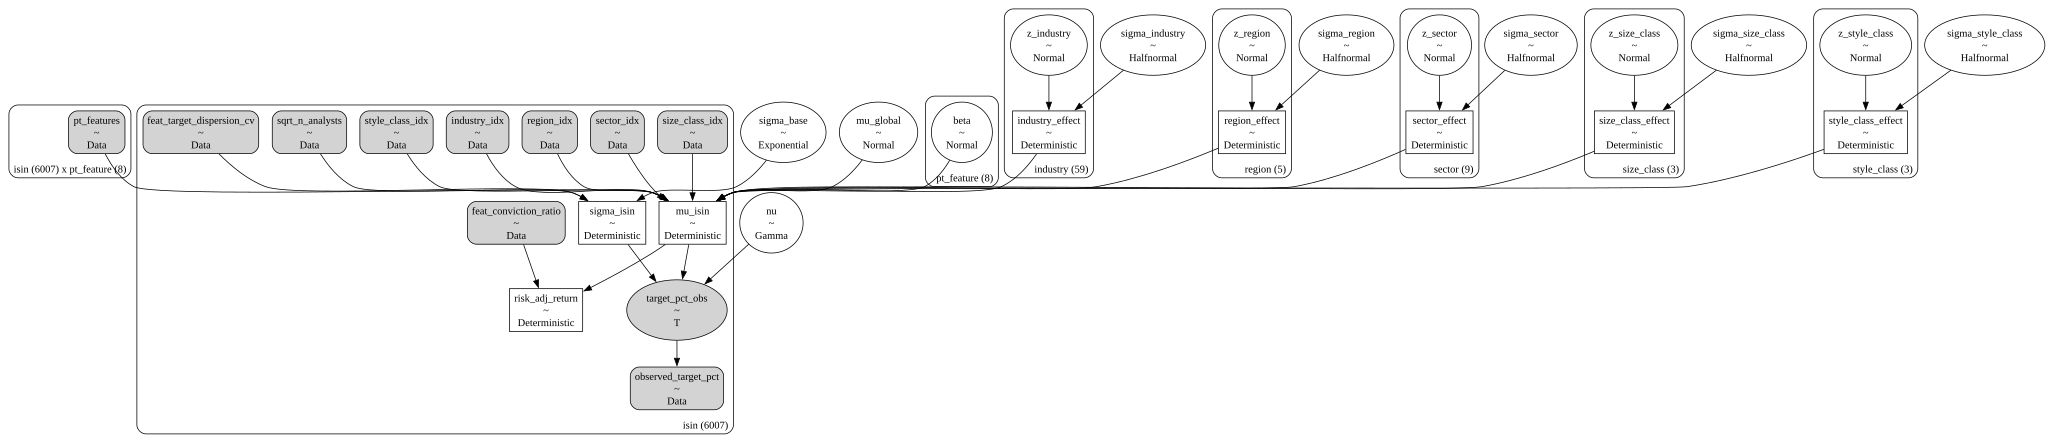

In [20]:
# 4.2  Cross-sectional price-target model — refactored fused builder.
#
# The previous fused model layered a 3-D MvGaussianRandomWalk on a TILED
# (isin, time, y_series) response tensor (Y = np.tile(snapshot, (1, T))) and a
# per-observation `expected_return` latent. Both are removed here:
#   * the tiling created T identical copies x D deterministically-related
#     series, inflating the effective sample size and making PSIS-LOO / WAIC
#     meaningless (the pointwise log-likelihood was dominated by duplicates);
#   * the per-observation latent saturated the likelihood (one free mean per
#     datum) and blew up Pareto-k.
# The refactored builder is a single-observation-per-ISIN hierarchical Student-t
# regression with multi-coord partial-pooling group effects. `mu_isin` is on
# the observed_target_pct scale (directly comparable); `risk_adj_return` is a
# derived, on-scale screening output (NOT the likelihood mean).
import numpy as np
import pymc as pm
import pytensor.tensor as pt

# Highest-signal, lowest-cardinality coords that receive a partial-pooling
# intercept, intersected with the coords actually present in the MV pull.
_CANDIDATE_GROUPS = ('industry', 'region', 'sector', 'size_class', 'style_class')
GROUP_EFFECTS = [c for c in _CANDIDATE_GROUPS if c in coord_idx]

# Heteroscedastic-sigma / risk-adjustment inputs (one row per ISIN). The
# dispersion CV and conviction ratio are MV-native `feat_*` columns when
# present; otherwise they fall back to zeros (sigma then reduces to the
# analyst-count-weighted base, risk_adj_return to mu_isin).
n_analysts_xs = model_df['n_analysts'].astype('float64').clip(lower=1).to_numpy()
sqrt_n_xs = np.sqrt(n_analysts_xs)
cv_xs = (model_df['feat_target_dispersion_cv'].astype('float64').fillna(0.0).to_numpy()
         if 'feat_target_dispersion_cv' in model_df.columns
         else np.zeros(len(model_df)))
conviction_xs = (model_df['feat_analyst_conviction'].astype('float64').fillna(0.0).to_numpy()
                 if 'feat_analyst_conviction' in model_df.columns
                 else np.zeros(len(model_df)))

RISK_PENALTY = 0.1


def build_fused_price_target_model(*, robust: bool = True) -> pm.Model:
    """Cross-sectional hierarchical Student-t price-target model (no MvGRW/tiling).

    One observation per ISIN on ``observed_target_pct``. The mean is a direct
    hierarchical regression with non-centred partial-pooling intercepts on each
    coord in ``GROUP_EFFECTS``; the scale is analyst-count-weighted and
    dispersion-driven. No per-observation latent, so the marginal posterior of
    ``mu_isin`` and PSIS-LOO are reliable.

    Parameters
    ----------
    robust : bool
        ``True`` -> heavy-tailed Student-t likelihood (default). ``False`` ->
        Normal-likelihood twin (differs ONLY in the observation distribution).
    """
    coords = {'isin': isin_labels, 'pt_feature': selected_predictors}
    for col in GROUP_EFFECTS:
        coords[col] = coord_uniques[col]

    with pm.Model(coords=coords) as model:
        Xd    = pm.Data('pt_features', X, dims=('isin', 'pt_feature'))
        cvd   = pm.Data('feat_target_dispersion_cv', cv_xs, dims='isin')
        convd = pm.Data('feat_analyst_conviction', conviction_xs, dims='isin')
        sqn   = pm.Data('sqrt_n_analysts', sqrt_n_xs, dims='isin')
        obs   = pm.Data('observed_target_pct', observed_target_pct, dims='isin')
        idx_data = {col: pm.Data(f'{col}_idx', coord_idx[col], dims='isin')
                    for col in GROUP_EFFECTS}

        # --- Mean: direct hierarchical regression (NO per-observation latent).
        mu_global = pm.Normal('mu_global', 0.0, 0.5)
        beta = pm.Normal('beta', 0.0, 0.25, dims='pt_feature')
        eta = mu_global + pt.dot(Xd, beta)
        for col in GROUP_EFFECTS:
            sigma_g = pm.HalfNormal(f'sigma_{col}', 0.25)
            z_g = pm.Normal(f'z_{col}', 0.0, 1.0, dims=col)
            group_effect = pm.Deterministic(f'{col}_effect', sigma_g * z_g, dims=col)
            eta = eta + group_effect[idx_data[col]]
        mu_isin = pm.Deterministic('mu_isin', eta, dims='isin')

        # --- Heteroscedastic, analyst-count-weighted scale.
        sigma_base = pm.Exponential('sigma_base', 1.0)  # no Abs->Sqrt inplace rewrite
        sigma_isin = pm.Deterministic('sigma_isin',
                                      sigma_base * (1.0 + cvd) / sqn, dims='isin')

        # --- Likelihood: robust Student-t by default; Normal twin optional.
        if robust:
            nu = pm.Gamma('nu', alpha=2.0, beta=0.1)
            pm.StudentT('target_pct_obs', nu=nu, mu=mu_isin, sigma=sigma_isin,
                        observed=obs, dims='isin')
        else:
            pm.Normal('target_pct_obs', mu=mu_isin, sigma=sigma_isin,
                      observed=obs, dims='isin')

        # --- Derived, on-scale risk-adjusted screening output.
        pm.Deterministic('risk_adj_return',
                         mu_isin * pt.exp(-RISK_PENALTY * convd), dims='isin')
    return model


price_target_model = build_fused_price_target_model(robust=True)
print(f'§4.2 — cross-sectional model on {len(observed_target_pct)} ISINs; '
      f'{len(selected_predictors)} predictors; group effects: {GROUP_EFFECTS}')
pm.model_to_graphviz(price_target_model)

## 5. Prior Predictive Checks

Sample from the prior to verify that priors imply a plausible distribution of analyst implied upside (`observed_target_pct`) centred near zero with heavy-tailed coverage of the empirical distribution.


In [21]:
# 5.0  Prior predictive — covers the cross-sectional hierarchical mean
# (mu_global, beta, group effects -> mu_isin), the heteroscedastic scale
# (sigma_base -> sigma_isin) and the likelihood degrees-of-freedom (nu).
_prior_var_names = [
    "mu_global", "beta", "mu_isin",
    *[f"sigma_{g}" for g in GROUP_EFFECTS],
    *[f"{g}_effect" for g in GROUP_EFFECTS],
    "sigma_base", "sigma_isin", "nu",
    "risk_adj_return", "target_pct_obs",
]
with price_target_model:
    prior_idata = pm.sample_prior_predictive(
        draws=1000,
        var_names=_prior_var_names,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )
prior_idata

Sampling: [beta, mu_global, nu, sigma_base, sigma_industry, sigma_region, sigma_sector, sigma_size_class, sigma_style_class, target_pct_obs, z_industry, z_region, z_sector, z_size_class, z_style_class]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:             (chain: 1, draw: 1000, isin: 6007, industry: 59,
│                                region: 5, size_class: 3, pt_feature: 8, sector: 9,
│                                style_class: 3)
│       Coordinates:
│         * chain               (chain) int64 8B 0
│         * draw                (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│         * isin                (isin) <U12 288kB 'US67066G1040' ... 'BRENJUACNOR9'
│         * industry            (industry) <U53 13kB 'Aerospace and Defense' ... 'Wir...
│         * region              (region) <U27 540B 'Africa / Middle East' ... 'United...
│         * size_class          (size_class) <U9 108B 'Large Cap' 'Mid Cap' 'Small Cap'
│         * pt_feature          (pt_feature) <U23 736B 'days_since_last_report' ... '...
│         * sector              (sector) <U22 792B 'Communication Services' ... 'Util...
│         * style_class         (style_class) <U6 72B 'Core' 'Growth' 'Value'
│       Data variables: (12/17)
│           mu_isin             (chain, draw, isin) float64 48MB 0.3692 1.289 ... 1.454
│           sigma_sector        (chain, draw) float64 8kB 0.02709 0.1034 ... 0.638
│           sigma_style_class   (chain, draw) float64 8kB 0.4123 0.3515 ... 0.2674
│           industry_effect     (chain, draw, industry) float64 472kB -0.2091 ... -0....
│           sigma_base          (chain, draw) float64 8kB 0.9688 1.828 ... 2.951 0.9722
│           sigma_region        (chain, draw) float64 8kB 0.4497 0.444 ... 0.1091 0.3128
│           ...                  ...
│           size_class_effect   (chain, draw, size_class) float64 24kB -0.008619 ... ...
│           sigma_isin          (chain, draw, isin) float64 48MB 0.1501 ... 0.8333
│           nu                  (chain, draw) float64 8kB 21.72 10.04 ... 10.88 13.4
│           beta                (chain, draw, pt_feature) float64 64kB -0.4797 ... -0...
│           sector_effect       (chain, draw, sector) float64 72kB -0.001105 ... -0.7153
│           style_class_effect  (chain, draw, style_class) float64 24kB 0.5173 ... 0....
│       Attributes:
│           created_at:                 2026-06-01T00:44:00.700438+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:         (chain: 1, draw: 1000, isin: 6007)
│       Coordinates:
│         * chain           (chain) int64 8B 0
│         * draw            (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * isin            (isin) <U12 288kB 'US67066G1040' ... 'BRENJUACNOR9'
│       Data variables:
│           target_pct_obs  (chain, draw, isin) float64 48MB 0.548 0.6105 ... 2.322
│       Attributes:
│           created_at:                 2026-06-01T00:44:00.705449+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:         (isin: 6007)
│       Coordinates:
│         * isin            (isin) <U12 288kB 'US67066G1040' ... 'BRENJUACNOR9'
│       Data variables:
│           target_pct_obs  (isin) float64 48kB 0.4058 0.9715 -0.2081 ... 1.79 0.5278
│       Attributes:
│           created_at:                 2026-06-01T00:44:00.707562+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constan

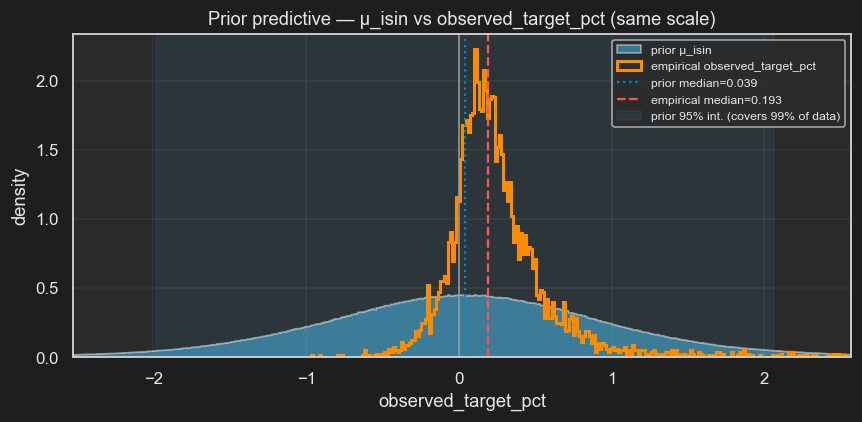

In [22]:
# 5.1  Prior on mu_isin vs empirical observed_target_pct.
# mu_isin is now on the SAME (observed_target_pct) scale as the data — no
# z-scaling needed — so the prior baseline and the empirical distribution are
# directly comparable.
empirical = model_df['observed_target_pct'].dropna().to_numpy()
prior_mu = prior_idata.prior['mu_isin'].values.reshape(-1)

# Shared, outlier-clipped bin edges so the two histograms are directly comparable.
lo, hi = np.percentile(np.concatenate([prior_mu, empirical]), [1, 99])
bin_edges = np.histogram_bin_edges(np.concatenate([prior_mu, empirical]),
                                   bins='auto', range=(lo, hi))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_mu, bins=bin_edges, density=True, histtype='stepfilled',
        alpha=0.5, color='#4FC3F7', label='prior μ_isin')
ax.hist(empirical, bins=bin_edges, density=True, histtype='step',
        lw=2, color='#FB8C00', label='empirical observed_target_pct')

ax.axvline(0, color='#9e9e9e', lw=1)
ax.axvline(np.median(prior_mu), color='#0288D1', ls=':',
           label=f'prior median={np.median(prior_mu):.3f}')
ax.axvline(np.median(empirical), color='#FF5252', ls='--',
           label=f'empirical median={np.median(empirical):.3f}')

# PPC coverage: share of empirical mass inside the prior's 95% interval.
p_lo, p_hi = np.percentile(prior_mu, [2.5, 97.5])
cover = np.mean((empirical >= p_lo) & (empirical <= p_hi))
ax.axvspan(p_lo, p_hi, color='#4FC3F7', alpha=0.08,
           label=f'prior 95% int. (covers {cover:.0%} of data)')

ax.set_xlim(lo, hi)
ax.set_title('Prior predictive — μ_isin vs observed_target_pct (same scale)')
ax.set_xlabel('observed_target_pct')
ax.set_ylabel('density')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

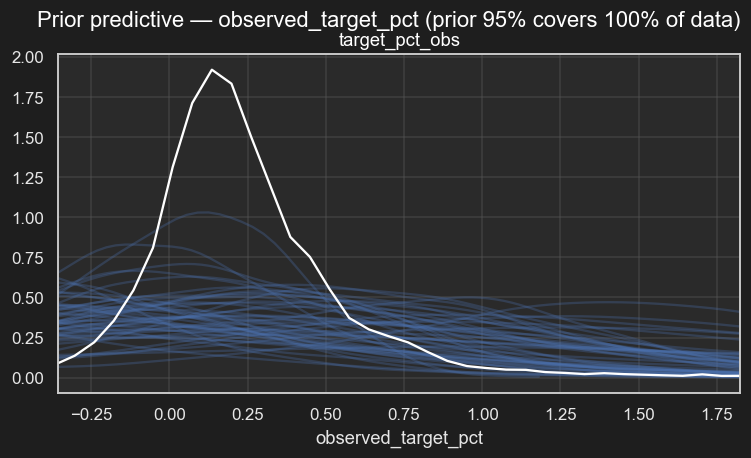

In [23]:
# 5.2  Prior predictive distribution of target_pct_obs vs the empirical data.
# Single `dims='isin'` response → one ECDF panel. We MUST opt into the observed
# overlay (plot_ppc_dist hides it by default for prior_predictive groups) so the
# check actually compares prior-predictive draws against the analyst data.
from arviz_plots import plot_ppc_dist

# Build layout/plot-collection options as a plain dict, then UNPACK with **.
# These are collected by plot_ppc_dist's variadic **pc_kwargs parameter.
ppc_layout = {
    "cols": "__variable__",
    "col_wrap": 1,
    "figure_kwargs": {"figsize": (8, 4)},
}

pc = plot_ppc_dist(
    prior_idata,
    group="prior_predictive",
    var_names=["target_pct_obs"],
    # Force the observed/empirical distribution overlay (hidden by default for
    # prior_predictive). The valid `visuals` keys for this arviz_plots version
    # are ('predictive_dist', 'observed_dist', 'title', 'remove_axis') — so the
    # overlay toggle is `observed_dist`, NOT `observed_data`.
    visuals={"observed_dist": True},
    **ppc_layout,  # NOT pc_kwargs=ppc_layout
)

# Focus the x-axis on the bulk; the Student-t prior predictive has heavy tails.
# Resolve the matplotlib Axes robustly from the figure the PlotCollection built
# (avoids the brittle `pc.viz["plot"].item()` lookup, whose node layout varies
# across arviz_plots versions / variable names).
emp = model_df["observed_target_pct"].dropna().to_numpy()
lo, hi = np.percentile(emp, [1, 99])

fig = pc.viz["figure"].item()
for ax in fig.axes:
    ax.set_xlim(lo, hi)
    ax.set_xlabel("observed_target_pct")

# Quantitative coverage verdict (consistent with §5.1).
pp = prior_idata.prior_predictive["target_pct_obs"].values.reshape(-1)
p_lo, p_hi = np.percentile(pp, [2.5, 97.5])
cover = np.mean((emp >= p_lo) & (emp <= p_hi))
pc.add_title(f"Prior predictive — observed_target_pct (prior 95% covers {cover:.0%} of data)")

pc.show()

## 6. Posterior Inference (NUTS)

Short NUTS run for notebook responsiveness — tune/draws can be increased for a production fit. The trace below feeds the posterior predictive checks and diagnostics in §7–§8.


In [24]:
# Sampler dispatch — nutpie → numpyro → pymc fallback. The cross-sectional
# hierarchical Student-t graph is supported by all three NUTS backends
# (nutpie/Rust, numpyro/JAX, PyMC pure-Python); we try them in priority order
# and fall back on the first that is installed and succeeds.
sample_kwargs = dict(
    draws=100, tune=100, chains=4, cores=2,
    target_accept=0.95, random_seed=RANDOM_SEED,
    progressbar=True, return_inferencedata=True,
    idata_kwargs={"log_likelihood": False},
)

# Probe sampler availability up-front so we don't waste time on samplers
# whose backends aren't installed (e.g. nutpie's Rust binary missing
# yields a bare FileNotFoundError that is hard to diagnose downstream).
import importlib.util as _ilu

_candidate_samplers = []
if _ilu.find_spec("nutpie") is not None:
    _candidate_samplers.append("nutpie")
if _ilu.find_spec("numpyro") is not None:
    _candidate_samplers.append("numpyro")
_candidate_samplers.append("pymc")  # always available — pure-Python NUTS
print(f"Available NUTS samplers (in priority order): {_candidate_samplers}")

sampling_errors = []
idata = None
for _sampler in _candidate_samplers:
    try:
        with price_target_model:
            idata = pm.sample(nuts_sampler=_sampler, **sample_kwargs)
        print(f"Sampled successfully with nuts_sampler={_sampler!r}.")
        break
    except Exception as e:  # pragma: no cover - environment-dependent fallback
        sampling_errors.append((_sampler, repr(e)))
        print(f"nuts_sampler={_sampler!r} failed: {e!r}")

if idata is None:
    raise RuntimeError(
        "All NUTS samplers failed:\n"
        + "\n".join(f"  - {s}: {err}" for s, err in sampling_errors)
    )

# Merge prior / prior_predictive groups into the posterior `idata` so the
# downstream PPC / diagnostic cells can read everything from one object.
from probabilistic_ml_model._pymc_arviz_compat import extend_datatree

idata = extend_datatree(idata, prior_idata)
idata

Available NUTS samplers (in priority order): ['nutpie', 'numpyro', 'pymc']


NUTS[nutpie]: [mu_global, beta, sigma_industry, z_industry, sigma_region, z_region, sigma_sector, z_sector, sigma_size_class, z_size_class, sigma_style_class, z_style_class, sigma_base, nu]


Output()

Sampled successfully with nuts_sampler='nutpie'.


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:             (chain: 4, draw: 100, pt_feature: 8, industry: 59,
│                                region: 5, sector: 9, size_class: 3, style_class: 3,
│                                isin: 6007)
│       Coordinates:
│         * chain               (chain) int64 32B 0 1 2 3
│         * draw                (draw) int64 800B 0 1 2 3 4 5 6 ... 93 94 95 96 97 98 99
│         * pt_feature          (pt_feature) object 64B 'days_since_last_report' ... ...
│         * industry            (industry) object 472B 'Aerospace and Defense' ... 'W...
│         * region              (region) object 40B 'Africa / Middle East' ... 'Unite...
│         * sector              (sector) object 72B 'Communication Services' ... 'Uti...
│         * size_class          (size_class) object 24B 'Large Cap' ... 'Small Cap'
│         * style_class         (style_class) object 24B 'Core' 'Growth' 'Value'
│         * isin                (isin) object 48kB 'US67066G1040' ... 'BRENJUACNOR9'
│       Data variables: (12/22)
│           mu_global           (chain, draw) float64 3kB 0.3187 0.1718 ... 0.3346
│           beta                (chain, draw, pt_feature) float64 26kB -0.1028 ... 0....
│           z_industry          (chain, draw, industry) float64 189kB -0.03171 ... 0....
│           z_region            (chain, draw, region) float64 16kB -0.1471 ... -1.074
│           z_sector            (chain, draw, sector) float64 29kB 1.741 ... -1.32
│           z_size_class        (chain, draw, size_class) float64 10kB -1.495 ... 2.264
│           ...                  ...
│           sector_effect       (chain, draw, sector) float64 29kB 0.1027 ... -0.04435
│           size_class_effect   (chain, draw, size_class) float64 10kB -0.1828 ... 0....
│           style_class_effect  (chain, draw, style_class) float64 10kB 0.03269 ... -...
│           mu_isin             (chain, draw, isin) float64 19MB 0.0911 ... 0.2959
│           sigma_isin          (chain, draw, isin) float64 19MB 0.05725 ... 0.3172
│           risk_adj_return     (chain, draw, isin) float64 19MB 0.08964 ... 0.2959
│       Attributes:
│           created_at:                 2026-06-01T00:44:40.737348+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.10
│           sampling_time:              23.877755403518677
│           tuning_steps:               100
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 100)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 800B 0 1 2 3 4 5 ... 95 96 97 98 99
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 3kB 8 7 6 6 6 8 ... 8 6 6 8 6
│           maxdepth_reached          (chain, draw) bool 400B False False ... False
│           step_size                 (chain, draw) float64 3kB 0.05851 ... 0.05793
│           transformation_update_id  (chain, draw) int64 3kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 3kB 0.05497 ... 0.05824
│           mean_tree_accept          (chain, draw) float64 3kB 0.9675 0.985 ... 0.9848
│           ...                        ...
│           fisher_distance           (chain, draw) float64 3kB 1.486e+03 ... 890.2
│           transformation_index      (chain, draw) int64 3kB 83 83 83 83 ... 84 84 84
│           diverging                 (chain, draw) bool 400B False False ... False
│           divergence_draw           (chain, draw) uint64 3kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 3kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 3kB nan nan nan ... nan nan
│   

Sampling: [target_pct_obs]


Output()

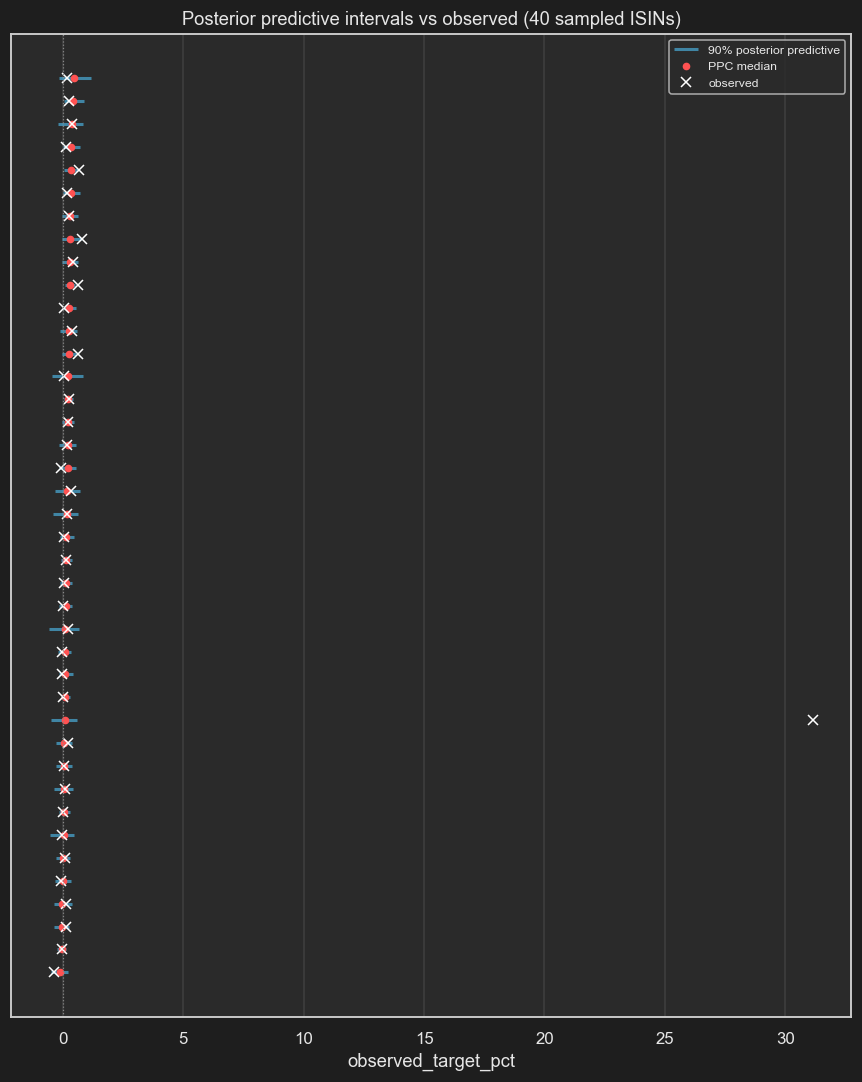

90% posterior-predictive interval empirical coverage: 90.2%


In [25]:
# 6.3  Posterior predictive vs observed (cross-sectional calibration).
# With a single response per ISIN we check calibration directly: per-ISIN
# posterior-predictive 90% interval + median against the observed value for a
# random subset, plus the empirical coverage of the 90% interval over ALL ISINs.
with price_target_model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=True,
        random_seed=RANDOM_SEED, progressbar=True,
    )

_ppc = idata.posterior_predictive['target_pct_obs'].stack(sample=('chain', 'draw'))
_med = _ppc.median('sample').values  # (isin,)
_q05 = _ppc.quantile(0.05, 'sample').values
_q95 = _ppc.quantile(0.95, 'sample').values
_obs = observed_target_pct

# Random subset of ISINs, ordered by predictive median for a readable strip.
_n_show = min(40, len(_obs))
_sel = rng.choice(len(_obs), size=_n_show, replace=False)
_sel = _sel[np.argsort(_med[_sel])]
ypos = np.arange(_n_show)

fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * _n_show)))
ax.hlines(ypos, _q05[_sel], _q95[_sel], color='#4FC3F7', alpha=0.6, lw=2,
          label='90% posterior predictive')
ax.plot(_med[_sel], ypos, 'o', color='#FF5252', ms=4, label='PPC median')
ax.plot(_obs[_sel], ypos, 'x', color='#FFFFFF', ms=6, label='observed')
ax.axvline(0, color='#888', ls=':', lw=0.8)
ax.set_yticks([])
ax.set_xlabel('observed_target_pct')
ax.set_title(f'Posterior predictive intervals vs observed ({_n_show} sampled ISINs)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Calibration diagnostic: a well-specified model covers ~90% of observations.
_cover = float(np.mean((_obs >= _q05) & (_obs <= _q95)))
print(f'90% posterior-predictive interval empirical coverage: {_cover:.1%}')

## 7. Posterior Predictive Checks

Compare the predictive distribution of `observed_target_pct` (analyst implied upside) against the observed sample. A well-calibrated Student-t regression should cover the empirical density including its tails.


Sampling: [target_pct_obs]


Output()

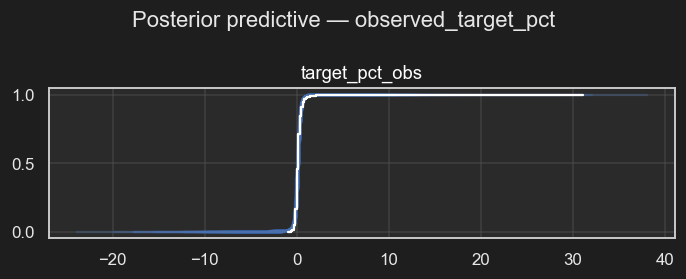

In [26]:
with price_target_model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=False,
        random_seed=RANDOM_SEED, progressbar=True,
    )

from arviz_plots import plot_ppc_dist

pc = plot_ppc_dist(
    idata,
    group="posterior_predictive",
    var_names=["target_pct_obs"],
    kind="ecdf",
    num_samples=200,
)
plt.suptitle("Posterior predictive — observed_target_pct")
plt.tight_layout()
plt.show()


In [27]:
# 7.1 Posterior sector-mean μ vs empirical sector target_pct_avg
import pandas as pd

sector_agg = (
    model_df.groupby('sector', as_index=False)
    .agg(empirical_target_pct=('observed_target_pct', 'mean'),
         n_obs=('isin', 'size'))
    .sort_values('sector').reset_index(drop=True)
)

# Note: the model defines the hierarchical sector intercept as
# pm.Deterministic('sector_effect', sigma_sector * z_sector, dims='sector').
# There is no 'alpha_sector' variable in idata.posterior.
post_sector_effect = (
    idata.posterior['sector_effect']
    .mean(dim=('chain', 'draw'))
    .to_pandas()
    .rename('posterior_sector_effect')
    .reset_index()
)

by_sector = sector_agg.merge(post_sector_effect, on='sector', how='left')
print(by_sector)


                   sector  empirical_target_pct  n_obs  \
0  Communication Services              0.279260    337   
1  Consumer Discretionary              0.315874    844   
2        Consumer Staples              0.242390    486   
3                  Energy              0.255917    346   
4             Health Care              0.493343    801   
5             Industrials              0.227778   1344   
6  Information Technology              0.144540    931   
7               Materials              0.224816    671   
8               Utilities              0.131983    247   

   posterior_sector_effect  
0                 0.029106  
1                 0.022489  
2                 0.008883  
3                -0.016668  
4                 0.056715  
5                -0.018677  
6                -0.060860  
7                 0.002664  
8                -0.041131  


## 8. MCMC Diagnostics

Convergence and sampler health: R-hat, ESS, divergences, trace plots, forest plot of predictor coefficients, and an ECDF of `p` — aligned with the ArviZ 1.0 diagnostic suite used in `probabilistic_ml_model.visualizations.arviz_diagnostics`.


In [28]:
# 8.1  R-hat / ESS summary across the cross-sectional parameter set.
# `requested` covers:
#   - cross-sectional baseline:   mu_global, beta
#   - hierarchical group effects:  sigma_<coord>, <coord>_effect for each coord
#   - likelihood scale / d.o.f.:   sigma_base, nu
posterior = idata.posterior
requested = ['mu_global', 'beta', 'sigma_base', 'nu']
for _grp in GROUP_EFFECTS:
    requested.extend([f'sigma_{_grp}', f'{_grp}_effect'])

available, skipped = [], []
for v in requested:
    if v not in posterior.data_vars:
        skipped.append((v, 'not in posterior'))
        continue
    da = posterior[v]
    non_sample_sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
    if any(s == 0 for s in non_sample_sizes):
        skipped.append((v, f'empty dim(s): {dict(da.sizes)}'))
        continue
    available.append(v)

if skipped:
    print('Skipping variables:')
    for name, reason in skipped:
        print(f'  - {name}: {reason}')

if not available:
    raise RuntimeError('No non-empty variables to summarise.')

summary = azs.summary(idata, var_names=available, round_to=4)
summary.sort_values('r_hat', ascending=False).head(30)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta[days_since_last_report],-0.0163,0.1399,-0.2414,0.2419,55.3837,64.3819,1.0793,0.0188,0.0144
beta[days_to_next_report],-0.0004,0.0659,-0.1236,0.1058,55.2367,64.3819,1.0793,0.0089,0.0068
beta[days_to_expected_report],-0.0374,0.1492,-0.2776,0.2435,55.5688,64.3819,1.0784,0.0201,0.0154
sigma_style_class,0.0563,0.0449,0.0169,0.1296,54.2930,134.0610,1.0742,0.0055,0.0104
style_class_effect[Core],0.0069,0.0371,-0.0479,0.0764,54.7789,109.7808,1.0670,0.0039,0.0041
style_class_effect[Growth],-0.0194,0.0373,-0.0728,0.0466,55.9289,112.4643,1.0617,0.0040,0.0043
style_class_effect[Value],0.0374,0.0375,-0.0150,0.1075,82.6537,116.0656,1.0517,0.0038,0.0042
size_class_effect[Small Cap],0.0341,0.0377,-0.0198,0.0854,92.1825,167.8425,1.0472,0.0036,0.0046
size_class_effect[Mid Cap],-0.0098,0.0374,-0.0625,0.0420,94.2674,155.9345,1.0431,0.0036,0.0047
sigma_size_class,0.0777,0.0616,0.0241,0.1743,81.3420,160.1987,1.0428,0.0051,0.0132


In [29]:
# 8.2  Divergences and aggregated R-hat / ESS.
# Per-variable max/min avoids the broadcast that a full to_array() would
# trigger over the per-coord group-effect dims.
n_div = int(idata.sample_stats['diverging'].sum())


def _non_empty_vars(ds):
    keep = []
    for name, da in ds.data_vars.items():
        sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
        if all(s > 0 for s in sizes):
            keep.append(name)
    return keep


posterior_tree = idata.posterior
posterior = posterior_tree.dataset if hasattr(posterior_tree, "dataset") else posterior_tree.to_dataset()

keep_vars = _non_empty_vars(posterior)
rhat_ds = azs.rhat(posterior[keep_vars])
ess_ds = azs.ess(posterior[keep_vars], method='bulk')

max_rhat = float(max(float(rhat_ds[v].max()) for v in rhat_ds.data_vars))
min_ess = float(min(float(ess_ds[v].min()) for v in ess_ds.data_vars))

# Surface the worst-offending hierarchical group-effect scales specifically:
# non-centred sigma_<coord> are the most prone to funnel pathologies.
_grp_keys = [f'sigma_{g}' for g in GROUP_EFFECTS if f'sigma_{g}' in rhat_ds.data_vars]
_grp_report = {v: (float(rhat_ds[v].max()), float(ess_ds[v].min()))
               for v in _grp_keys}

print(f'Divergences: {n_div}')
print(f'Max R-hat:   {max_rhat:.4f}')
print(f'Min ESS:     {min_ess:.1f}')
if _grp_report:
    print('Group-effect scale diagnostics (max R-hat, min ESS):')
    for v, (r, e) in _grp_report.items():
        print(f'  - {v:>20s}: r_hat={r:.3f}, ess_bulk={e:.1f}')

Divergences: 0
Max R-hat:   1.0793
Min ESS:     47.5
Group-effect scale diagnostics (max R-hat, min ESS):
  -       sigma_industry: r_hat=1.029, ess_bulk=136.4
  -         sigma_region: r_hat=1.027, ess_bulk=132.1
  -         sigma_sector: r_hat=1.029, ess_bulk=89.8
  -     sigma_size_class: r_hat=1.043, ess_bulk=81.3
  -    sigma_style_class: r_hat=1.074, ess_bulk=54.3


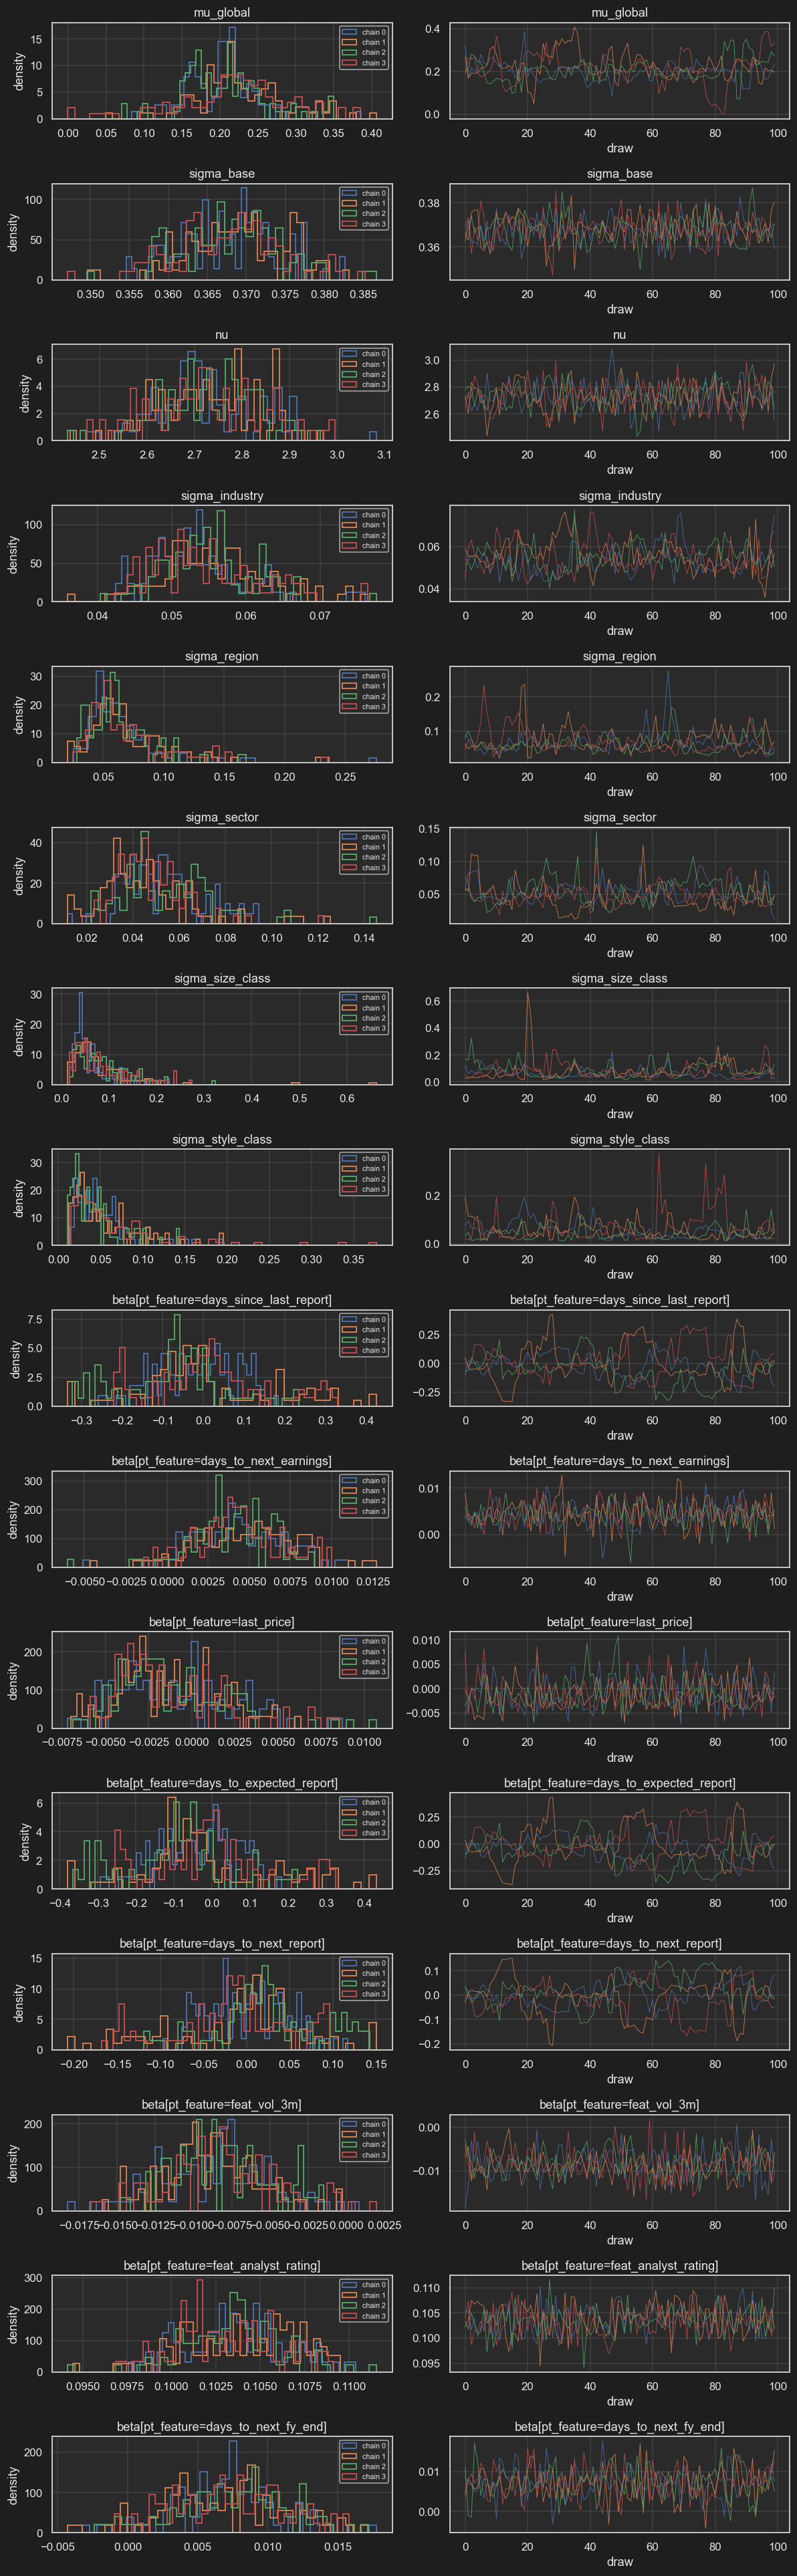

In [30]:
# 8.3  Trace + density plots for the key parameters (manual, backend-agnostic).
# Covers the cross-sectional baseline (mu_global, beta), the likelihood
# scale / d.o.f. (sigma_base, nu) and every hierarchical group-effect scale
# (sigma_<coord>). Per-coord `<coord>_effect` vectors are summarised in the
# §8.5 forest plot rather than blown up into one trace panel each.
import numpy as np
import matplotlib.pyplot as plt

_group_scale_vars = tuple(f'sigma_{g}' for g in GROUP_EFFECTS)

trace_vars = [v for v in (
    'mu_global', 'sigma_base', 'nu',
    *_group_scale_vars,
    'beta',
) if v in available]


def _iter_param_slices(da):
    """Yield (label_suffix, 2D array of shape (chain, draw)) for each scalar
    slice of a posterior DataArray. Works for scalar params (no extra dims),
    vector params (one extra dim, e.g. 'sector', 'pt_feature'), and matrix
    params (multiple extra dims)."""
    extra_dims = [d for d in da.dims if d not in ('chain', 'draw')]
    if not extra_dims:
        yield '', da.values
        return
    stacked = da.stack(_extra=extra_dims)
    for i in range(stacked.sizes['_extra']):
        sl = stacked.isel(_extra=i)
        coord_bits = []
        for d in extra_dims:
            val = sl.coords[d].values.item() if d in sl.coords else i
            coord_bits.append(f"{d}={val}")
        yield '[' + ', '.join(coord_bits) + ']', sl.values  # (chain, draw)


if trace_vars:
    posterior = idata.posterior
    rows = []
    for v in trace_vars:
        if v not in posterior:
            continue
        da = posterior[v]
        if any(da.sizes[d] == 0 for d in da.dims):
            continue
        for suffix, arr in _iter_param_slices(da):
            rows.append((f"{v}{suffix}", arr))

    if not rows:
        print('No non-empty posterior variables to plot.')
    else:
        n = len(rows)
        fig, axes = plt.subplots(n, 2, figsize=(11, 2.2 * n), squeeze=False)
        for i, (label, arr) in enumerate(rows):
            ax_density, ax_trace = axes[i, 0], axes[i, 1]
            n_chains = arr.shape[0]
            for c in range(n_chains):
                vals = arr[c]
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                ax_density.hist(vals, bins=40, density=True,
                                histtype='step', linewidth=1.2,
                                label=f'chain {c}')
            ax_density.set_title(label)
            ax_density.set_ylabel('density')
            if n_chains > 1:
                ax_density.legend(fontsize=7, loc='best')
            for c in range(n_chains):
                ax_trace.plot(arr[c], linewidth=0.6, alpha=0.85,
                              label=f'chain {c}')
            ax_trace.set_title(label)
            ax_trace.set_xlabel('draw')
        plt.tight_layout()
        plt.show()
else:
    print('No trace-eligible variables available.')

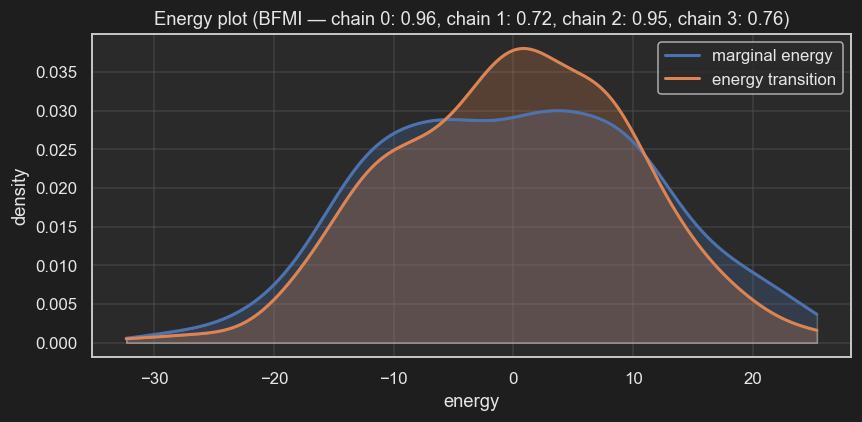

In [31]:
# 8.4 Energy plot (NUTS health) — single execution path, model-agnostic.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Robustly get groups for both InferenceData and DataTree
_groups_attr = getattr(idata, "groups", None)
if callable(_groups_attr):
    _groups = _groups_attr()  # classic arviz.InferenceData
else:
    _groups = tuple(_groups_attr) if _groups_attr is not None else ()  # xarray.DataTree

# DataTree group names start with '/', InferenceData uses plain names — normalize:
_group_names = {g.lstrip("/").split("/")[-1] for g in _groups}

if "sample_stats" in _group_names and "energy" in idata.sample_stats.data_vars:
    energy = idata.sample_stats["energy"]
    extra_dims = [d for d in energy.dims if d not in ("chain", "draw")]
    if extra_dims:
        energy = energy.mean(dim=extra_dims)  # collapse stray dims safely
    e = energy.values  # shape (chain, draw)

    marginal = (e - e.mean()).ravel()
    transition = np.diff(e, axis=1).ravel()
    transition = transition - transition.mean() + marginal.mean()

    # BFMI per chain (Betancourt 2016). Values < 0.3 typically indicate the
    # sampler is struggling — e.g. a poorly-identified hierarchical scale
    # (sigma_<coord>) inducing a funnel.
    bfmi = np.array([
        np.sum(np.diff(e[c]) ** 2) / np.sum((e[c] - e[c].mean()) ** 2)
        for c in range(e.shape[0])
    ])

    fig, ax = plt.subplots(figsize=(8, 4))
    grid = np.linspace(min(marginal.min(), transition.min()),
                       max(marginal.max(), transition.max()), 400)

    kde_m = gaussian_kde(marginal)
    kde_t = gaussian_kde(transition)
    ax.plot(grid, kde_m(grid), label="marginal energy", lw=2)
    ax.plot(grid, kde_t(grid), label="energy transition", lw=2)
    ax.fill_between(grid, kde_m(grid), alpha=0.25)
    ax.fill_between(grid, kde_t(grid), alpha=0.25)

    bfmi_str = ", ".join(f"chain {i}: {b:.2f}" for i, b in enumerate(bfmi))
    ax.set_title(f"Energy plot (BFMI — {bfmi_str})")
    ax.set_xlabel("energy")
    ax.set_ylabel("density")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("sample_stats.energy not available — skipping energy plot.")


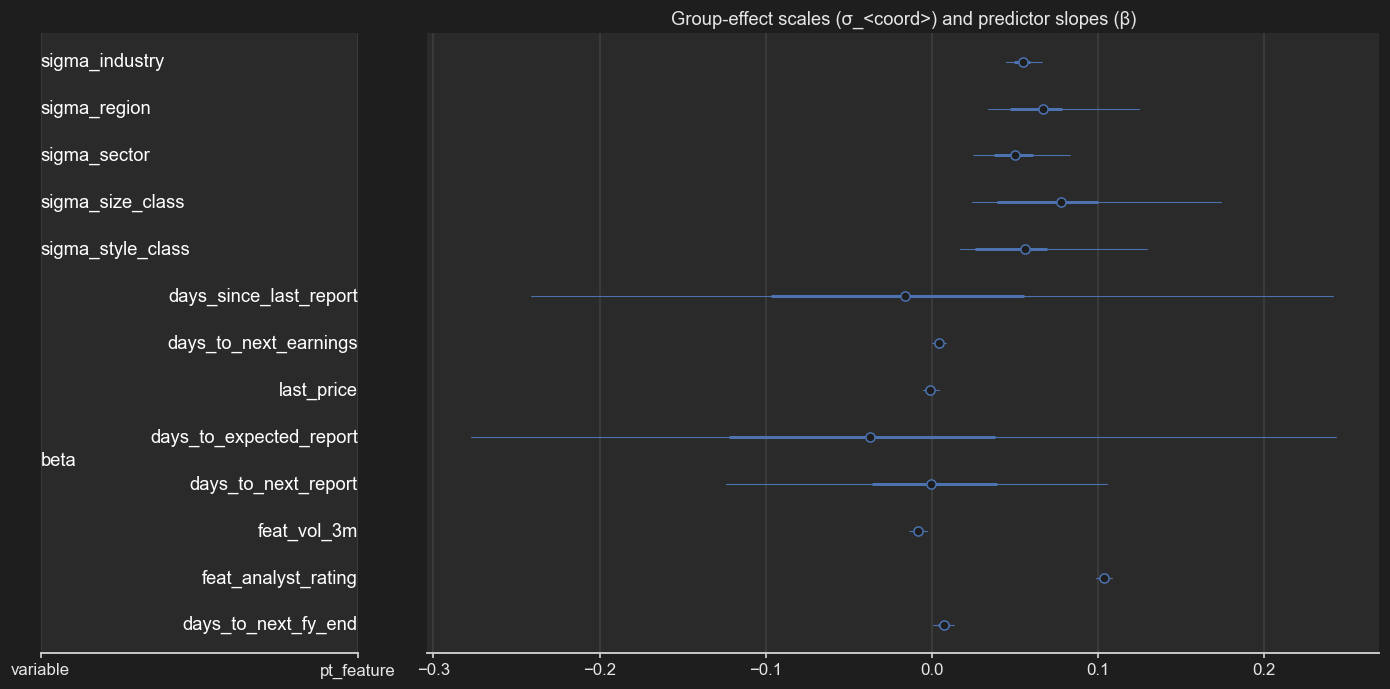

In [32]:
# 8.5  Forest plot of the hierarchical group-effect scales and predictor slopes.
# A wider `sigma_<coord>` means that coordinate (sector / industry / region /
# size_class / style_class) explains more cross-sectional dispersion in the
# analyst implied upside; the `beta` panel shows the standardised-predictor
# slopes. Replaces the previous diagonal-GRW innovation-scale forest.
import arviz_plots as azp

_forest_vars = [f'sigma_{g}' for g in GROUP_EFFECTS
                if f'sigma_{g}' in idata.posterior.data_vars]
_forest_vars += [v for v in ('beta',) if v in idata.posterior.data_vars]

if _forest_vars:
    azp.plot_forest(
        idata,
        var_names=_forest_vars,
        combined=True,
    )
    plt.title('Group-effect scales (σ_<coord>) and predictor slopes (β)')
    plt.tight_layout()
    plt.show()
else:
    print('No group-effect / beta variables in posterior — skipped.')

### Summary

- §2 — EDA over `pml.mv_pymc_price_target` columns using `vw_pymc_feature_catalogue` (`pymc_role` / `feature_role` / `feature_alias`). Classification coords (`region, country, trading_country, exchange, unit, style_class, size_class, sector, industry`) profiled.
- §3 — per-column summary statistics merged with the catalogue, rolled up by `(pymc_role, feature_role, category)`; analyst-sentiment / valuation predictors visualised.
- §4 — **cross-sectional hierarchical Student-t** PyMC model with `pm.Data` containers named after MV aliases (`pt_features`, `feat_target_dispersion_cv`, `feat_analyst_conviction`, `sqrt_n_analysts`, `observed_target_pct`, `<coord>_idx`). One observation per ISIN; multi-coord partial-pooling intercepts (`sector, industry, region, size_class, style_class`). `mu_isin` lives on the `observed_target_pct` scale; `risk_adj_return` is a derived screening output. The previous tiled `(isin, time, y_series)` MvGRW and per-observation latent were removed so the marginal posterior and PSIS-LOO are reliable and comparable.
- §5 — prior predictive checks: `mu_isin` vs empirical `observed_target_pct` (same scale) and the prior predictive ECDF of `target_pct_obs`.
- §6 — NUTS posterior inference with `nutpie → numpyro → pymc` fallback; posterior-predictive interval-vs-observed calibration with empirical 90% coverage.
- §7 — posterior predictive ECDF and `sector_effect` vs empirical sector means.
- §8 — R-hat / ESS / divergences across the parameter set (`mu_global`, `beta`, `sigma_{sector,industry,region,size_class,style_class}`, `<coord>_effect`, `sigma_base`, `nu`); trace + density panels, energy plot with BFMI, and a forest plot of the group-effect scales and predictor slopes.